In [1]:
from dotenv import load_dotenv
load_dotenv()
import os
import numpy as np
from pixell import enmap, enplot, reproject
import glob
import matplotlib.pyplot as plt
import emcee, corner
from astropy.io import fits
import sys
from astropy import units as u, constants as const
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2
import yaml
import itertools
from pixell import enmap

import bandpass as bp
import covariance as cov
import model
import utils as ut

import SZpack as SZ

from astropy.coordinates import SkyCoord
import astropy.units as u

## Extract chain

In [2]:
chain = "/home/gill/research/ACT/bridge/results/ajay/final_runs/case23/chain.h5"
sampler = emcee.backends.HDFBackend(chain)
samples = sampler.get_chain(discard=50000, flat=True, thin=500)

## Extract arrays of tSZ, kSZ, and total SZ signals for A401, A399, filament

In [3]:
const_c = 299792458.0 # m / s
const_k_B = 1.380649e-23 # J / K
const_h = 6.626070149999999e-25 # J / GHz

c1_signals_tSZ = []
c2_signals_tSZ = []
fil_signals_tSZ = []

c1_signals_kSZ = []
c2_signals_kSZ = []
fil_signals_kSZ = []

c1_signals_total_sz = []
c2_signals_total_sz = []
fil_signals_total_sz = []

c1_signals_total = []
c2_signals_total = []
fil_signals_total = []

dust_c1_signals = []
dust_c2_signals = []
dust_fil_signals = []

nfreq_samps = 500

# calculate the signals now
for sample in samples:
    c1_tau = sample[6]
    c1_Te = sample[7]
    c1_A_D = sample[8]  
    c1_v = sample[9] * -1

    c2_tau = sample[16]
    c2_Te = sample[17]
    c2_A_D = sample[18]
    c2_v = sample[19] * -1

    fil_tau = sample[24]
    fil_Te = sample[25]
    fil_A_D = sample[26]
    fil_v = sample[27] * -1

    # cluster 1 (tSZ)
    SZ_params_c1_tSZ = SZ.parameters()
    SZ_params_c1_tSZ.betao = 0.001233586736861806
    SZ_params_c1_tSZ.runmode = 'full'
    SZ_params_c1_tSZ.T_order = 10
    SZ_params_c1_tSZ.beta_order = 2

    # Dust parameters
    freq_ref = 545 
    T_D = 20 
    beta_D = 1.5

    c1_muo = -0.5566122489553409
    c1_z = 0.073664
    c1_vc_idx = 0
    c1_Te_idx = c1_Te
    c1_tau_idx = c1_tau

    SZ_params_c1_tSZ.muo = c1_muo
    SZ_params_c1_tSZ.Dtau = c1_tau_idx
    SZ_params_c1_tSZ.Te = c1_Te_idx
    SZ_params_c1_tSZ.betac = np.abs(c1_vc_idx) * 1000 / const_c
    SZ_params_c1_tSZ.set_x_array(0.1, 20, nfreq_samps)  

    if c1_vc_idx < 0:
        SZ_params_c1_tSZ.muc = 1
    else:
        SZ_params_c1_tSZ.muc = -1

    # Set higher order terms to zero
    SZ_params_c1_tSZ.means_assign_omegas(0, 0, 0)
    SZ_params_c1_tSZ.means_assign_sigmas(0, 0, 0)
    SZ_params_c1_tSZ.means_kappa = 0 

    SZ_c1_signal_tSZ = SZ.compute_combo(SZ_params_c1_tSZ, DI=True)  * 10**6 # Jy/sr
    c1_signals_tSZ.append(SZ_c1_signal_tSZ)

    # cluster 1 (kSZ)
    SZ_params_c1_kSZ = SZ.parameters()
    SZ_params_c1_kSZ.betao = 0.001233586736861806
    SZ_params_c1_kSZ.runmode = 'full'
    SZ_params_c1_kSZ.T_order = 10
    SZ_params_c1_kSZ.beta_order = 2

    c1_vc_idx = c1_v
    c1_Te_idx = 1e-20
    c1_tau_idx = c1_tau

    SZ_params_c1_kSZ.muo = c1_muo
    SZ_params_c1_kSZ.Dtau = c1_tau_idx
    SZ_params_c1_kSZ.Te = c1_Te_idx
    SZ_params_c1_kSZ.betac = np.abs(c1_vc_idx) * 1000 / const_c
    SZ_params_c1_kSZ.set_x_array(0.1, 20, nfreq_samps)

    if c1_vc_idx < 0:
        SZ_params_c1_kSZ.muc = 1
    else:
        SZ_params_c1_kSZ.muc = -1

    # Set higher order terms to zero
    SZ_params_c1_kSZ.means_assign_omegas(0, 0, 0)
    SZ_params_c1_kSZ.means_assign_sigmas(0, 0, 0)
    SZ_params_c1_kSZ.means_kappa = 0

    SZ_c1_signal_kSZ = SZ.compute_combo(SZ_params_c1_kSZ, DI=True) * 10**6 # Jy/sr
    c1_signals_kSZ.append(SZ_c1_signal_kSZ)

    # # cluster 1 (total - tSZ + kSZ)
    # SZ_params_c1_total = SZ.parameters()
    # SZ_params_c1_total.betao = 0.001233586736861806
    # SZ_params_c1_total.runmode = 'full'
    # SZ_params_c1_total.T_order = 10
    # SZ_params_c1_total.beta_order = 2

    # c1_vc_idx = c1_v
    # c1_Te_idx = c1_Te
    # c1_tau_idx = c1_tau

    # SZ_params_c1_total.muo = c1_muo
    # SZ_params_c1_total.Dtau = c1_tau_idx
    # SZ_params_c1_total.Te = c1_Te_idx
    # SZ_params_c1_total.betac = np.abs(c1_vc_idx) * 1000 / const_c
    # SZ_params_c1_total.set_x_array(0.1, 20, nfreq_samps)

    # if c1_vc_idx < 0:
    #     SZ_params_c1_total.muc = 1
    # else:
    #     SZ_params_c1_total.muc = -1

    # # Set higher order terms to zero
    # SZ_params_c1_total.means_assign_omegas(0, 0, 0)
    # SZ_params_c1_total.means_assign_sigmas(0, 0, 0)
    # SZ_params_c1_total.means_kappa = 0

    # SZ_c1_signal_total = SZ.compute_combo(SZ_params_c1_total, DI=True) * 10**6  # Jy/sr
    c1_signals_total_sz.append(SZ_c1_signal_tSZ + SZ_c1_signal_kSZ)

    # dust cluster 1
    c1_AD_idx = c1_A_D
    x_dust = (const_h * SZ_params_c1_kSZ.nucmb * (1 + c1_z)) / (const_k_B * T_D)     
    x_ref = (const_h * freq_ref) / (const_k_B * T_D)
    term_ref = (np.exp(x_ref) - 1)
    term_dust = (np.exp(x_dust) - 1)
    term_power = (SZ_params_c1_kSZ.nucmb * (1 + c1_z) / freq_ref)**(beta_D + 3)
    I_dust_c1 = c1_AD_idx * term_power * (term_ref / term_dust) 
    dust_c1_signals.append(I_dust_c1)

    c1_signals_total.append(SZ_c1_signal_tSZ + SZ_c1_signal_kSZ + I_dust_c1)

    # cluster 2 (tSZ)
    SZ_params_c2_tSZ = SZ.parameters()
    SZ_params_c2_tSZ.betao = 0.001233586736861806
    SZ_params_c2_tSZ.runmode = 'full'
    SZ_params_c2_tSZ.T_order = 10
    SZ_params_c2_tSZ.beta_order = 2

    c2_muo = -0.5606024845891494
    c2_z = 0.071806
    c2_vc_idx = 0
    c2_Te_idx = c2_Te
    c2_tau_idx = c2_tau

    SZ_params_c2_tSZ.muo = c2_muo
    SZ_params_c2_tSZ.Dtau = c2_tau_idx
    SZ_params_c2_tSZ.Te = c2_Te_idx
    SZ_params_c2_tSZ.betac = np.abs(c2_vc_idx) * 1000 / const_c
    SZ_params_c2_tSZ.set_x_array(0.1, 20, nfreq_samps)  

    if c2_vc_idx < 0:
        SZ_params_c2_tSZ.muc = 1
    else:
        SZ_params_c2_tSZ.muc = -1

    # Set higher order terms to zero
    SZ_params_c2_tSZ.means_assign_omegas(0, 0, 0)
    SZ_params_c2_tSZ.means_assign_sigmas(0, 0, 0)
    SZ_params_c2_tSZ.means_kappa = 0

    SZ_c2_signal_tSZ = SZ.compute_combo(SZ_params_c2_tSZ, DI=True) * 10**6
    c2_signals_tSZ.append(SZ_c2_signal_tSZ)

    # cluster 2 (kSZ)
    SZ_params_c2_kSZ = SZ.parameters()
    SZ_params_c2_kSZ.betao = 0.001233586736861806
    SZ_params_c2_kSZ.runmode = 'full'
    SZ_params_c2_kSZ.T_order = 10
    SZ_params_c2_kSZ.beta_order = 2

    c2_vc_idx = c2_v
    c2_Te_idx = 1e-20
    c2_tau_idx = c2_tau

    SZ_params_c2_kSZ.muo = c2_muo
    SZ_params_c2_kSZ.Dtau = c2_tau_idx
    SZ_params_c2_kSZ.Te = c2_Te_idx
    SZ_params_c2_kSZ.betac = np.abs(c2_vc_idx) * 1000 / const_c
    SZ_params_c2_kSZ.set_x_array(0.1, 20, nfreq_samps)

    if c2_vc_idx < 0:
        SZ_params_c2_kSZ.muc = 1
    else:
        SZ_params_c2_kSZ.muc = -1

    # Set higher order terms to zero
    SZ_params_c2_kSZ.means_assign_omegas(0, 0, 0)
    SZ_params_c2_kSZ.means_assign_sigmas(0, 0, 0)
    SZ_params_c2_kSZ.means_kappa = 0

    SZ_c2_signal_kSZ = SZ.compute_combo(SZ_params_c2_kSZ, DI=True) * 10**6
    c2_signals_kSZ.append(SZ_c2_signal_kSZ)

    # cluster 2 (total - tSZ + kSZ)
    SZ_params_c2_total = SZ.parameters()
    SZ_params_c2_total.betao = 0.001233586736861806
    SZ_params_c2_total.runmode = 'full'
    SZ_params_c2_total.T_order = 10
    SZ_params_c2_total.beta_order = 2

    c2_vc_idx = c2_v
    c2_Te_idx = c2_Te
    c2_tau_idx = c2_tau

    SZ_params_c2_total.muo = c2_muo
    SZ_params_c2_total.Dtau = c2_tau_idx
    SZ_params_c2_total.Te = c2_Te_idx
    SZ_params_c2_total.betac = np.abs(c2_vc_idx) * 1000 / const_c
    SZ_params_c2_total.set_x_array(0.1, 20, nfreq_samps)

    if c2_vc_idx < 0:
        SZ_params_c2_total.muc = 1
    else:
        SZ_params_c2_total.muc = -1

    # Set higher order terms to zero
    SZ_params_c2_total.means_assign_omegas(0, 0, 0)
    SZ_params_c2_total.means_assign_sigmas(0, 0, 0)
    SZ_params_c2_total.means_kappa = 0

    # SZ_c2_signal_total = SZ.compute_combo(SZ_params_c2_total, DI=True) * 10**6
    c2_signals_total_sz.append(SZ_c1_signal_tSZ + SZ_c1_signal_kSZ)

    # dust cluster 2
    c2_AD_idx = c2_A_D
    x_dust = (const_h * SZ_params_c2_total.nucmb * (1 + c2_z)) / (const_k_B * T_D)     
    x_ref = (const_h * freq_ref) / (const_k_B * T_D)
    term_ref = (np.exp(x_ref) - 1)
    term_dust = (np.exp(x_dust) - 1)
    term_power = (SZ_params_c2_total.nucmb * (1 + c2_z) / freq_ref)**(beta_D + 3)
    I_dust_c2 = c2_AD_idx * term_power * (term_ref / term_dust) 
    dust_c2_signals.append(I_dust_c2)

    c2_signals_total.append(SZ_c1_signal_tSZ + SZ_c1_signal_kSZ + I_dust_c2)

    # filament (tSZ)
    SZ_params_fil_tSZ = SZ.parameters()
    SZ_params_fil_tSZ.betao = 0.001233586736861806
    SZ_params_fil_tSZ.runmode = 'full'
    SZ_params_fil_tSZ.T_order = 10
    SZ_params_fil_tSZ.beta_order = 2

    fil_muo = -0.5576451231598584
    fil_z = 0.072735
    fil_vc_idx = 0
    fil_Te_idx = fil_Te
    fil_tau_idx = fil_tau

    SZ_params_fil_tSZ.muo = fil_muo
    SZ_params_fil_tSZ.Dtau = fil_tau_idx
    SZ_params_fil_tSZ.Te = fil_Te_idx
    SZ_params_fil_tSZ.betac = np.abs(fil_vc_idx) * 1000 / const_c
    SZ_params_fil_tSZ.set_x_array(0.1, 20, nfreq_samps)

    if fil_vc_idx < 0:
        SZ_params_fil_tSZ.muc = 1
    else:
        SZ_params_fil_tSZ.muc = -1

    # Set higher order terms to zero
    SZ_params_fil_tSZ.means_assign_omegas(0, 0, 0)
    SZ_params_fil_tSZ.means_assign_sigmas(0, 0, 0)
    SZ_params_fil_tSZ.means_kappa = 0

    SZ_fil_signal_tSZ = SZ.compute_combo(SZ_params_fil_tSZ, DI=True) * 10**6
    fil_signals_tSZ.append(SZ_fil_signal_tSZ)

    # filament (kSZ)
    SZ_params_fil_kSZ = SZ.parameters()
    SZ_params_fil_kSZ.betao = 0.001233586736861806
    SZ_params_fil_kSZ.runmode = 'full'
    SZ_params_fil_kSZ.T_order = 10
    SZ_params_fil_kSZ.beta_order = 2

    fil_vc_idx = fil_v
    fil_Te_idx = 1e-20
    fil_tau_idx = fil_tau

    SZ_params_fil_kSZ.muo = fil_muo
    SZ_params_fil_kSZ.Dtau = fil_tau_idx
    SZ_params_fil_kSZ.Te = fil_Te_idx
    SZ_params_fil_kSZ.betac = np.abs(fil_vc_idx) * 1000 / const_c
    SZ_params_fil_kSZ.set_x_array(0.1, 20, nfreq_samps)

    if fil_vc_idx < 0:
        SZ_params_fil_kSZ.muc = 1
    else:
        SZ_params_fil_kSZ.muc = -1

    # Set higher order terms to zero
    SZ_params_fil_kSZ.means_assign_omegas(0, 0, 0)
    SZ_params_fil_kSZ.means_assign_sigmas(0, 0, 0)
    SZ_params_fil_kSZ.means_kappa = 0

    SZ_fil_signal_kSZ = SZ.compute_combo(SZ_params_fil_kSZ, DI=True) * 10**6
    fil_signals_kSZ.append(SZ_fil_signal_kSZ)

    # filament (total - tSZ + kSZ)
    SZ_params_fil_total = SZ.parameters()
    SZ_params_fil_total.betao = 0.001233586736861806
    SZ_params_fil_total.runmode = 'full'
    SZ_params_fil_total.T_order = 10
    SZ_params_fil_total.beta_order = 2

    fil_vc_idx = fil_v
    fil_Te_idx = fil_Te
    fil_tau_idx = fil_tau

    SZ_params_fil_total.muo = fil_muo
    SZ_params_fil_total.Dtau = fil_tau_idx
    SZ_params_fil_total.Te = fil_Te_idx
    SZ_params_fil_total.betac = np.abs(fil_vc_idx) * 1000 / const_c
    SZ_params_fil_total.set_x_array(0.1, 20, nfreq_samps)

    if fil_vc_idx < 0:
        SZ_params_fil_total.muc = 1
    else:
        SZ_params_fil_total.muc = -1

    # Set higher order terms to zero
    SZ_params_fil_total.means_assign_omegas(0, 0, 0)
    SZ_params_fil_total.means_assign_sigmas(0, 0, 0)
    SZ_params_fil_total.means_kappa = 0

    #SZ_fil_signal_total = SZ.compute_combo(SZ_params_fil_total, DI=True) * 10**6
    fil_signals_total_sz.append(SZ_fil_signal_kSZ + SZ_fil_signal_tSZ)

    # dust (filament)
    fil_AD_idx = fil_A_D
    x_dust = (const_h * SZ_params_fil_total.nucmb * (1 + fil_z)) / (const_k_B * T_D)
    x_ref = (const_h * freq_ref) / (const_k_B * T_D)
    term_ref = (np.exp(x_ref) - 1)
    term_dust = (np.exp(x_dust) - 1)
    term_power = (SZ_params_fil_total.nucmb * (1 + fil_z) / freq_ref)**(beta_D + 3)
    I_dust_fil = fil_AD_idx * term_power * (term_ref / term_dust) 
    dust_fil_signals.append(I_dust_fil)

    fil_signals_total.append(SZ_fil_signal_kSZ + SZ_fil_signal_tSZ + I_dust_fil)

In [4]:
## Cluster 1
# process dust signals (c1 only)
dust_c1_signals_stacked = np.stack(dust_c1_signals) / 1000
dust_c1_signals_percentile_16 = np.percentile(dust_c1_signals_stacked, 16, axis=0)
dust_c1_signals_percentile_84 = np.percentile(dust_c1_signals_stacked, 84, axis=0)
dust_c1_signals_mean = np.percentile(dust_c1_signals_stacked, 50, axis=0)

# Process tSZ signals (c1 only)
c1_signals_tSZ_stacked = np.stack(c1_signals_tSZ) / 1000
c1_signals_tSZ_percentile_16 = np.percentile(c1_signals_tSZ_stacked, 16, axis=0)
c1_signals_tSZ_percentile_84 = np.percentile(c1_signals_tSZ_stacked, 84, axis=0)
c1_signals_tSZ_mean = np.median(c1_signals_tSZ_stacked, axis=0)

# Process kSZ signals (c1 only)
c1_signals_kSZ_stacked = np.stack(c1_signals_kSZ) / 1000
c1_signals_kSZ_percentile_16 = np.percentile(c1_signals_kSZ_stacked, 16, axis=0)
c1_signals_kSZ_percentile_84 = np.percentile(c1_signals_kSZ_stacked, 84, axis=0)
c1_signals_kSZ_mean = np.median(c1_signals_kSZ_stacked, axis=0)

# Process total SZ signals (tSZ + kSZ) (c1 only)
c1_signals_total_sz_stacked = np.stack(c1_signals_total_sz) / 1000
c1_signals_total_sz_percentile_16 = np.percentile(c1_signals_total_sz_stacked, 16, axis=0)
c1_signals_total_sz_percentile_84 = np.percentile(c1_signals_total_sz_stacked, 84, axis=0)
c1_signals_total_sz_mean = np.median(c1_signals_total_sz_stacked, axis=0)

# # Process total (SZ + dust) (c1 only)
c1_signals_total_stacked = np.stack(c1_signals_total) / 1000
c1_signals_total_percentile_16 = np.percentile(c1_signals_total_stacked, 16, axis=0)
c1_signals_total_percentile_84 = np.percentile(c1_signals_total_stacked, 84, axis=0)
c1_signals_total_mean = np.median(c1_signals_total_stacked, axis=0)

## Cluster 2
dust_c2_signals_stacked = np.stack(dust_c2_signals) / 1000
dust_c2_signals_percentile_16 = np.percentile(dust_c2_signals_stacked, 16, axis=0)
dust_c2_signals_percentile_84 = np.percentile(dust_c2_signals_stacked, 84, axis=0)
dust_c2_signals_mean = np.percentile(dust_c2_signals_stacked, 50, axis=0)

# Process tSZ signals (c2 only)
c2_signals_tSZ_stacked = np.stack(c2_signals_tSZ) / 1000
c2_signals_tSZ_percentile_16 = np.percentile(c2_signals_tSZ_stacked, 16, axis=0)
c2_signals_tSZ_percentile_84 = np.percentile(c2_signals_tSZ_stacked, 84, axis=0)
c2_signals_tSZ_mean = np.median(c2_signals_tSZ_stacked, axis=0)

# Process kSZ signals (c2 only)
c2_signals_kSZ_stacked = np.stack(c2_signals_kSZ) / 1000
c2_signals_kSZ_percentile_16 = np.percentile(c2_signals_kSZ_stacked, 16, axis=0)
c2_signals_kSZ_percentile_84 = np.percentile(c2_signals_kSZ_stacked, 84, axis=0)
c2_signals_kSZ_mean = np.median(c2_signals_kSZ_stacked, axis=0)

# Process total SZ signals (tSZ + kSZ) (c2 only)
c2_signals_total_sz_stacked = np.stack(c2_signals_total_sz) / 1000
c2_signals_total_sz_percentile_16 = np.percentile(c2_signals_total_sz_stacked, 16, axis=0)
c2_signals_total_sz_percentile_84 = np.percentile(c2_signals_total_sz_stacked, 84, axis=0)
c2_signals_total_sz_mean = np.median(c2_signals_total_sz_stacked, axis=0)

# # Process total (SZ + dust) (c2 only)
c2_signals_total_stacked = np.stack(c2_signals_total) / 1000
c2_signals_total_percentile_16 = np.percentile(c2_signals_total_stacked, 16, axis=0)
c2_signals_total_percentile_84 = np.percentile(c2_signals_total_stacked, 84, axis=0)
c2_signals_total_mean = np.median(c2_signals_total_stacked, axis=0)

## Filament
dust_fil_signals_stacked = np.stack(dust_fil_signals) / 1000
dust_fil_signals_percentile_16 = np.percentile(dust_fil_signals_stacked, 16, axis=0)
dust_fil_signals_percentile_84 = np.percentile(dust_fil_signals_stacked, 84, axis=0)
dust_fil_signals_mean = np.percentile(dust_fil_signals_stacked, 50, axis=0)

# Process tSZ signals (filament only)
fil_signals_tSZ_stacked = np.stack(fil_signals_tSZ) / 1000
fil_signals_tSZ_percentile_16 = np.percentile(fil_signals_tSZ_stacked, 16, axis=0)
fil_signals_tSZ_percentile_84 = np.percentile(fil_signals_tSZ_stacked, 84, axis=0)
fil_signals_tSZ_mean = np.median(fil_signals_tSZ_stacked, axis=0)

# Process kSZ signals (filament only)
fil_signals_kSZ_stacked = np.stack(fil_signals_kSZ) / 1000
fil_signals_kSZ_percentile_16 = np.percentile(fil_signals_kSZ_stacked, 16, axis=0)
fil_signals_kSZ_percentile_84 = np.percentile(fil_signals_kSZ_stacked, 84, axis=0)
fil_signals_kSZ_mean = np.median(fil_signals_kSZ_stacked, axis=0)

# Process total SZ signals (tSZ + kSZ) (filament only)
fil_signals_total_sz_stacked = np.stack(fil_signals_total_sz) / 1000
fil_signals_total_sz_percentile_16 = np.percentile(fil_signals_total_sz_stacked, 16, axis=0)
fil_signals_total_sz_percentile_84 = np.percentile(fil_signals_total_sz_stacked, 84, axis=0)
fil_signals_total_sz_mean = np.median(fil_signals_total_sz_stacked, axis=0)

# # Process total (SZ + dust) (filament only)
fil_signals_total_stacked = np.stack(fil_signals_total) / 1000
fil_signals_total_percentile_16 = np.percentile(fil_signals_total_stacked, 16, axis=0)
fil_signals_total_percentile_84 = np.percentile(fil_signals_total_stacked, 84, axis=0)
fil_signals_total_mean = np.median(fil_signals_total_stacked, axis=0)


## Corner plots to look for correlations (tSZ and kSZ)

In [ ]:
# for frequencies 150 GHz, 218 GHz, and 353 GHz, plot a scatter or corner plot between the tSZ and kSZ signals for c1

# Define target frequencies
target_frequencies = [150, 223, 353]
frequency_array = SZ_params_c1_tSZ.nucmb

# Find closest indices for target frequencies
freq_indices = []
for target_freq in target_frequencies:
    closest_idx = np.argmin(np.abs(frequency_array - target_freq))
    freq_indices.append(closest_idx)
    print(f"Target: {target_freq} GHz, Actual: {frequency_array[closest_idx]:.1f} GHz, Index: {closest_idx}")

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (freq_idx, target_freq) in enumerate(zip(freq_indices, target_frequencies)):
    # Extract tSZ and kSZ values at this frequency for all MCMC samples
    tsz_values = c1_signals_tSZ_stacked[:, freq_idx]
    ksz_values = c1_signals_kSZ_stacked[:, freq_idx]
    
    # Calculate correlation coefficient
    correlation = np.corrcoef(tsz_values, ksz_values)[0, 1]
    
    # Create scatter plot
    axes[i].scatter(tsz_values, ksz_values, alpha=0.6, s=20, color='C0')
    axes[i].set_xlabel('tSZ Signal [kJy/sr]')
    axes[i].set_ylabel('kSZ Signal [kJy/sr]')
    axes[i].set_title(f'{frequency_array[freq_idx]:.0f} GHz\nCorrelation: {correlation:.3f}')
    axes[i].grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(tsz_values, ksz_values, 1)
    p = np.poly1d(z)
    axes[i].plot(tsz_values, p(tsz_values), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.suptitle('tSZ vs kSZ Correlation for Abell 401 at Different Frequencies', y=1.02, fontsize=16)
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
for i, (freq_idx, target_freq) in enumerate(zip(freq_indices, target_frequencies)):
    tsz_values = c1_signals_tSZ_stacked[:, freq_idx]
    ksz_values = c1_signals_kSZ_stacked[:, freq_idx]
    correlation = np.corrcoef(tsz_values, ksz_values)[0, 1]
    
    print(f"{frequency_array[freq_idx]:.0f} GHz:")
    print(f"  Correlation: {correlation:.4f}")
    print(f"  tSZ range: [{tsz_values.min():.1f}, {tsz_values.max():.1f}] kJy/sr")
    print(f"  kSZ range: [{ksz_values.min():.1f}, {ksz_values.max():.1f}] kJy/sr")

# Create scatter plot between kSZ and dust signals at the same frequencies
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for j, (freq_idx, target_freq) in enumerate(zip(freq_indices, target_frequencies)):
    # Extract kSZ and dust values at this frequency for all MCMC samples
    ksz_values = c1_signals_kSZ_stacked[:, freq_idx]
    dust_values = dust_c1_signals_stacked[:, freq_idx]
    
    # Calculate correlation coefficient
    correlation = np.corrcoef(ksz_values, dust_values)[0, 1]
    
    # Create scatter plot
    axes[j].scatter(ksz_values, dust_values, alpha=0.6, s=20, color='C1')
    axes[j].set_xlabel('kSZ Signal [kJy/sr]')
    axes[j].set_ylabel('Dust Signal [kJy/sr]')
    axes[j].set_title(f'{frequency_array[freq_idx]:.0f} GHz\nCorrelation: {correlation:.3f}')
    axes[j].grid(True, alpha=0.3)
    
    # Add trend line
    z_ksz_dust = np.polyfit(ksz_values, dust_values, 1)
    p_ksz_dust = np.poly1d(z_ksz_dust)
    axes[j].plot(ksz_values, p_ksz_dust(ksz_values), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.suptitle('kSZ vs Dust Correlation for Abell 401 at Different Frequencies', y=1.02, fontsize=16)
plt.show()

# Print summary statistics for kSZ vs dust
print("\nkSZ vs Dust Summary Statistics:")
for i, (freq_idx, target_freq) in enumerate(zip(freq_indices, target_frequencies)):
    ksz_values = c1_signals_kSZ_stacked[:, freq_idx]
    dust_values = dust_c1_signals_stacked[:, freq_idx]
    correlation = np.corrcoef(ksz_values, dust_values)[0, 1]
    
    print(f"{frequency_array[freq_idx]:.0f} GHz:")
    print(f"  Correlation: {correlation:.4f}")
    print(f"  kSZ range: [{ksz_values.min():.1f}, {ksz_values.max():.1f}] kJy/sr")
    print(f"  Dust range: [{dust_values.min():.1f}, {dust_values.max():.1f}] kJy/sr")

# Create scatter plots for tSZ vs dust
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for k, (freq_idx, target_freq) in enumerate(zip(freq_indices, target_frequencies)):
    # Extract tSZ and dust values at this frequency for all MCMC samples
    tsz_values = c1_signals_tSZ_stacked[:, freq_idx]
    dust_values = dust_c1_signals_stacked[:, freq_idx]
    
    # Calculate correlation coefficient
    correlation = np.corrcoef(tsz_values, dust_values)[0, 1]
    
    # Create scatter plot
    axes[k].scatter(tsz_values, dust_values, alpha=0.6, s=20, color='C2')
    axes[k].set_xlabel('tSZ Signal [kJy/sr]')
    axes[k].set_ylabel('Dust Signal [kJy/sr]')
    axes[k].set_title(f'{frequency_array[freq_idx]:.0f} GHz\nCorrelation: {correlation:.3f}')
    axes[k].grid(True, alpha=0.3)
    
    # Add trend line
    z_tsz_dust = np.polyfit(tsz_values, dust_values, 1)
    p_tsz_dust = np.poly1d(z_tsz_dust)
    axes[k].plot(tsz_values, p_tsz_dust(tsz_values), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.suptitle('tSZ vs Dust Correlation for Abell 401 at Different Frequencies', y=1.02, fontsize=16)
plt.show()

# Print summary statistics for tSZ vs dust
print("\ntSZ vs Dust Summary Statistics:")
for i, (freq_idx, target_freq) in enumerate(zip(freq_indices, target_frequencies)):
    tsz_values = c1_signals_tSZ_stacked[:, freq_idx]
    dust_values = dust_c1_signals_stacked[:, freq_idx]
    correlation = np.corrcoef(tsz_values, dust_values)[0, 1]
    
    print(f"{frequency_array[freq_idx]:.0f} GHz:")
    print(f"  Correlation: {correlation:.4f}")
    print(f"  tSZ range: [{tsz_values.min():.1f}, {tsz_values.max():.1f}] kJy/sr")
    print(f"  Dust range: [{dust_values.min():.1f}, {dust_values.max():.1f}] kJy/sr")


In [ ]:
# v401 = samples[:, 9] 
# v399 = samples[:, 19]
# plt.figure(figsize=(10, 6))
# plt.hist(v401, bins=30, color='blue', alpha=0.7)
# plt.hist(v399, bins=30, color='red', alpha=0.7)
# plt.xlabel('Value')
# plt.ylabel('Frequency')
# plt.title('Histogram of A401 velocities')
# plt.grid(True, alpha=0.3)
# plt.show()


In [ ]:
# process dust signals (c1 only)
dust_c1_signals_stacked = np.stack(dust_c1_signals) / 1000
dust_c1_signals_percentile_16 = np.percentile(dust_c1_signals_stacked, 16, axis=0)
dust_c1_signals_percentile_84 = np.percentile(dust_c1_signals_stacked, 84, axis=0)
dust_c1_signals_mean = np.percentile(dust_c1_signals_stacked, 50, axis=0)

# Process tSZ signals (c1 only)
c1_signals_tSZ_stacked = np.stack(c1_signals_tSZ) / 1000
c1_signals_tSZ_percentile_16 = np.percentile(c1_signals_tSZ_stacked, 16, axis=0)
c1_signals_tSZ_percentile_84 = np.percentile(c1_signals_tSZ_stacked, 84, axis=0)
c1_signals_tSZ_mean = np.median(c1_signals_tSZ_stacked, axis=0)

# Process kSZ signals (c1 only)
c1_signals_kSZ_stacked = np.stack(c1_signals_kSZ) / 1000
c1_signals_kSZ_percentile_16 = np.percentile(c1_signals_kSZ_stacked, 16, axis=0)
c1_signals_kSZ_percentile_84 = np.percentile(c1_signals_kSZ_stacked, 84, axis=0)
c1_signals_kSZ_mean = np.median(c1_signals_kSZ_stacked, axis=0)

# Process total SZ signals (tSZ + kSZ) (c1 only)
c1_signals_total_sz_stacked = np.stack(c1_signals_total_sz) / 1000
c1_signals_total_sz_percentile_16 = np.percentile(c1_signals_total_sz_stacked, 16, axis=0)
c1_signals_total_sz_percentile_84 = np.percentile(c1_signals_total_sz_stacked, 84, axis=0)
c1_signals_total_sz_mean = np.median(c1_signals_total_sz_stacked, axis=0)

# # Process total (SZ + dust) (c1 only)
# c1_signals_total_stacked = np.stack(c1_signals_total) / 1000
# c1_signals_total_percentile_16 = np.percentile(c1_signals_total_stacked, 16, axis=0)
# c1_signals_total_percentile_84 = np.percentile(c1_signals_total_stacked, 84, axis=0)
# c1_signals_total_mean = np.median(c1_signals_total_stacked, axis=0)

In [ ]:
# process dust signals (c2 only)
dust_c2_signals_stacked = np.stack(dust_c2_signals) / 1000
dust_c2_signals_percentile_16 = np.percentile(dust_c2_signals_stacked, 16, axis=0)
dust_c2_signals_percentile_84 = np.percentile(dust_c2_signals_stacked, 84, axis=0)
dust_c2_signals_mean = np.percentile(dust_c2_signals_stacked, 50, axis=0)

# Process tSZ signals (c2 only)
c2_signals_tSZ_stacked = np.stack(c2_signals_tSZ) / 1000
c2_signals_tSZ_percentile_16 = np.percentile(c2_signals_tSZ_stacked, 16, axis=0)
c2_signals_tSZ_percentile_84 = np.percentile(c2_signals_tSZ_stacked, 84, axis=0)
c2_signals_tSZ_mean = np.median(c2_signals_tSZ_stacked, axis=0)

# Process kSZ signals (c2 only)
c2_signals_kSZ_stacked = np.stack(c2_signals_kSZ) / 1000
c2_signals_kSZ_percentile_16 = np.percentile(c2_signals_kSZ_stacked, 16, axis=0)
c2_signals_kSZ_percentile_84 = np.percentile(c2_signals_kSZ_stacked, 84, axis=0)
c2_signals_kSZ_mean = np.median(c2_signals_kSZ_stacked, axis=0)

# Process total SZ signals (tSZ + kSZ) (c2 only)
c2_signals_total_sz_stacked = np.stack(c2_signals_total_sz) / 1000
c2_signals_total_sz_percentile_16 = np.percentile(c2_signals_total_sz_stacked, 16, axis=0)
c2_signals_total_sz_percentile_84 = np.percentile(c2_signals_total_sz_stacked, 84, axis=0)
c2_signals_total_sz_mean = np.median(c2_signals_total_sz_stacked, axis=0)

# Process total (SZ + dust) (c2 only)
c2_signals_total_stacked = np.stack(c2_signals_total) / 1000
c2_signals_total_percentile_16 = np.percentile(c2_signals_total_stacked, 16, axis=0)
c2_signals_total_percentile_84 = np.percentile(c2_signals_total_stacked, 84, axis=0)
c2_signals_total_mean = np.median(c2_signals_total_stacked, axis=0)

In [ ]:
# for frequencies 150 GHz, 218 GHz, and 353 GHz, plot a scatter or corner plot between the tSZ and kSZ signals for c2

# Define target frequencies
target_frequencies = [150, 220, 353]
frequency_array = SZ_params_c1_tSZ.nucmb

# Find closest indices for target frequencies
freq_indices = []
for target_freq in target_frequencies:
    closest_idx = np.argmin(np.abs(frequency_array - target_freq))
    freq_indices.append(closest_idx)
    print(f"Target: {target_freq} GHz, Actual: {frequency_array[closest_idx]:.1f} GHz, Index: {closest_idx}")

# Create figure with subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (freq_idx, target_freq) in enumerate(zip(freq_indices, target_frequencies)):
    # Extract tSZ and kSZ values at this frequency for all MCMC samples
    tsz_values = c2_signals_tSZ_stacked[:, freq_idx]
    ksz_values = c2_signals_kSZ_stacked[:, freq_idx]
    
    # Calculate correlation coefficient
    correlation = np.corrcoef(tsz_values, ksz_values)[0, 1]
    
    # Create scatter plot
    axes[i].scatter(tsz_values, ksz_values, alpha=0.6, s=20, color='C0')
    axes[i].set_xlabel('tSZ Signal [kJy/sr]')
    axes[i].set_ylabel('kSZ Signal [kJy/sr]')
    axes[i].set_title(f'{frequency_array[freq_idx]:.0f} GHz\nCorrelation: {correlation:.3f}')
    axes[i].grid(True, alpha=0.3)
    
    # Add trend line
    z = np.polyfit(tsz_values, ksz_values, 1)
    p = np.poly1d(z)
    axes[i].plot(tsz_values, p(tsz_values), "r--", alpha=0.8, linewidth=2)

plt.tight_layout()
plt.suptitle('tSZ vs kSZ Correlation for Abell 399 at Different Frequencies', y=1.02, fontsize=16)
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
for i, (freq_idx, target_freq) in enumerate(zip(freq_indices, target_frequencies)):
    tsz_values = c2_signals_tSZ_stacked[:, freq_idx]
    ksz_values = c2_signals_kSZ_stacked[:, freq_idx]
    correlation = np.corrcoef(tsz_values, ksz_values)[0, 1]
    
    print(f"{frequency_array[freq_idx]:.0f} GHz:")
    print(f"  Correlation: {correlation:.4f}")
    print(f"  tSZ range: [{tsz_values.min():.1f}, {tsz_values.max():.1f}] kJy/sr")
    print(f"  kSZ range: [{ksz_values.min():.1f}, {ksz_values.max():.1f}] kJy/sr")


In [ ]:
import matplotlib.ticker as ticker

plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=28)

fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(111)

# Plot C1 signals (Abell 401) - blue for cluster 1
ax1.plot(SZ_params_c1_tSZ.nucmb, c1_signals_tSZ_mean, label='tSZ', color='C0', linestyle='-.', lw=1)
ax1.fill_between(SZ_params_c1_tSZ.nucmb, 
                 c1_signals_tSZ_percentile_16, 
                 c1_signals_tSZ_percentile_84,
                 color='C0', alpha=.2
                 )

ax1.plot(SZ_params_c1_kSZ.nucmb, c1_signals_kSZ_mean, label='kSZ', color='C1', linestyle='--', lw=1)
ax1.fill_between(SZ_params_c1_kSZ.nucmb,
                 c1_signals_kSZ_percentile_16,
                 c1_signals_kSZ_percentile_84,
                 color='C1', alpha=.2
                 )

ax1.plot(SZ_params_c1_kSZ.nucmb, c1_signals_total_sz_mean, label='Total SZ', color='C2', linestyle='--', lw=1)
ax1.fill_between(SZ_params_c1_kSZ.nucmb,
                 c1_signals_total_sz_percentile_16,
                 c1_signals_total_sz_percentile_84,
                 color='C2', alpha=.2
                 )

# plot dust signals
ax1.plot(SZ_params_c1_tSZ.nucmb, dust_c1_signals_mean, label='Dust', color='C3', linestyle='--', lw=1)
ax1.fill_between(SZ_params_c1_tSZ.nucmb,
                 dust_c1_signals_percentile_16,
                 dust_c1_signals_percentile_84,
                 color='C3', alpha=.2
                 )

ax1.plot(SZ_params_c1_tSZ.nucmb, c1_signals_total_mean, label='Total \n(SZ + dust)', color='C4', linestyle='-', lw=3)

ax1.fill_between(SZ_params_c1_tSZ.nucmb,
                 c1_signals_total_percentile_16,
                 c1_signals_total_percentile_84,
                 color='C4', alpha=0.4)

ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.set_xlabel(r'Dimensionless frequency, $x= h\nu/k_{\rm B}T_{\rm CMB}$')
ax1.set_ylabel('$\Delta I$ [kJy/sr]')
ax1.legend(fontsize=18, frameon=0, loc='upper left', ncol=1, edgecolor='black')

# plt.axhline(0, color='grey', linestyle='--', alpha=0.2)
plt.xlabel('Frequency (GHz)')
plt.xticks(np.arange(0, 1200, 200))
#plt.savefig("../plots/sz_spectrum_tSZ_kSZ_total.pdf", bbox_inches='tight', dpi=400)

# vertical line at freq = 218
plt.axvline(218, color='grey', linestyle='--')
plt.text(174, 110, 'tSZ null', color='grey', fontsize=16, ha='center', va='bottom')
plt.ylim(-190, 800)
plt.xlim(0, 600)
ax1.set_yticks(np.arange(-200, 801, 200))
ax1.set_xticks(np.arange(0, 601, 100))
plt.text(250, 600, "Abell 401")
# ax1.grid()
plt.savefig("../plots/sz_dust_spectrum_a401.pdf", bbox_inches='tight', dpi=400)
plt.show()


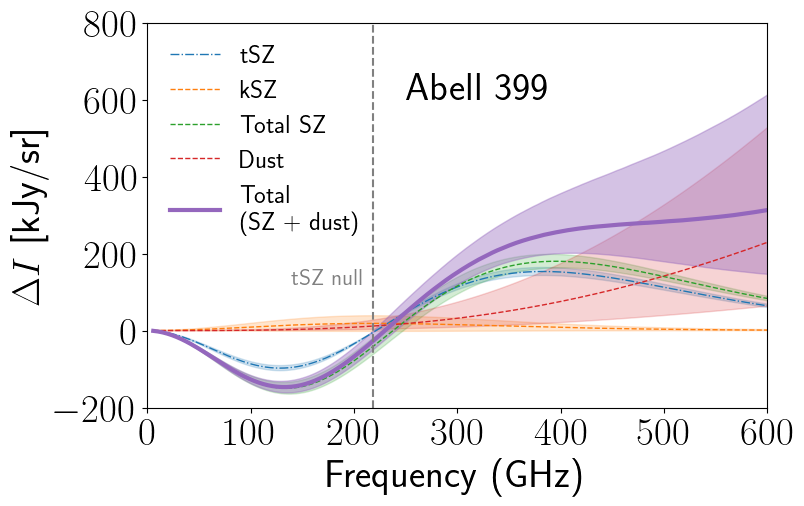

In [5]:
import matplotlib.ticker as ticker

plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=28)

fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(111)

# Plot C2 signals (Abell 399) - blue for cluster 2
ax1.plot(SZ_params_c2_tSZ.nucmb, c2_signals_tSZ_mean, label='tSZ', color='C0', linestyle='-.', lw=1)
ax1.fill_between(SZ_params_c2_tSZ.nucmb, 
                 c2_signals_tSZ_percentile_16, 
                 c2_signals_tSZ_percentile_84,
                 color='C0', alpha=.2
                 )

ax1.plot(SZ_params_c2_kSZ.nucmb, c2_signals_kSZ_mean, label='kSZ', color='C1', linestyle='--', lw=1)
ax1.fill_between(SZ_params_c2_kSZ.nucmb,
                 c2_signals_kSZ_percentile_16,
                 c2_signals_kSZ_percentile_84,
                 color='C1', alpha=.2
                 )

ax1.plot(SZ_params_c2_kSZ.nucmb, c2_signals_total_sz_mean, label='Total SZ', color='C2', linestyle='--', lw=1)
ax1.fill_between(SZ_params_c2_kSZ.nucmb,
                 c2_signals_total_sz_percentile_16,
                 c2_signals_total_sz_percentile_84,
                 color='C2', alpha=.2
                 )

# plot dust signals
ax1.plot(SZ_params_c2_tSZ.nucmb, dust_c2_signals_mean, label='Dust', color='C3', linestyle='--', lw=1)
ax1.fill_between(SZ_params_c2_tSZ.nucmb,
                 dust_c2_signals_percentile_16,
                 dust_c2_signals_percentile_84,
                 color='C3', alpha=.2
                 )

ax1.plot(SZ_params_c2_tSZ.nucmb, c2_signals_total_mean, label='Total \n(SZ + dust)', color='C4', linestyle='-', lw=3)

ax1.fill_between(SZ_params_c2_tSZ.nucmb,
                 c2_signals_total_percentile_16,
                 c2_signals_total_percentile_84,
                 color='C4', alpha=0.4)

ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.set_xlabel(r'Dimensionless frequency, $x= h\nu/k_{\rm B}T_{\rm CMB}$')
ax1.set_ylabel('$\Delta I$ [kJy/sr]')
ax1.legend(fontsize=18, frameon=0, loc='upper left', ncol=1, edgecolor='black')

# plt.axhline(0, color='grey', linestyle='--', alpha=0.2)
plt.xlabel('Frequency (GHz)')
plt.xticks(np.arange(0, 1200, 200))
#plt.savefig("../plots/sz_spectrum_tSZ_kSZ_total.pdf", bbox_inches='tight', dpi=400)

# vertical line at freq = 218
plt.axvline(218, color='grey', linestyle='--')
plt.text(174, 110, 'tSZ null', color='grey', fontsize=16, ha='center', va='bottom')
plt.ylim(-190, 800)
plt.xlim(0, 600)
ax1.set_yticks(np.arange(-200, 801, 200))
ax1.set_xticks(np.arange(0, 601, 100))
plt.text(250, 600, "Abell 399")
# ax1.grid()
plt.savefig("../plots/sz_dust_spectrum_a399.pdf", bbox_inches='tight', dpi=400)
plt.show()


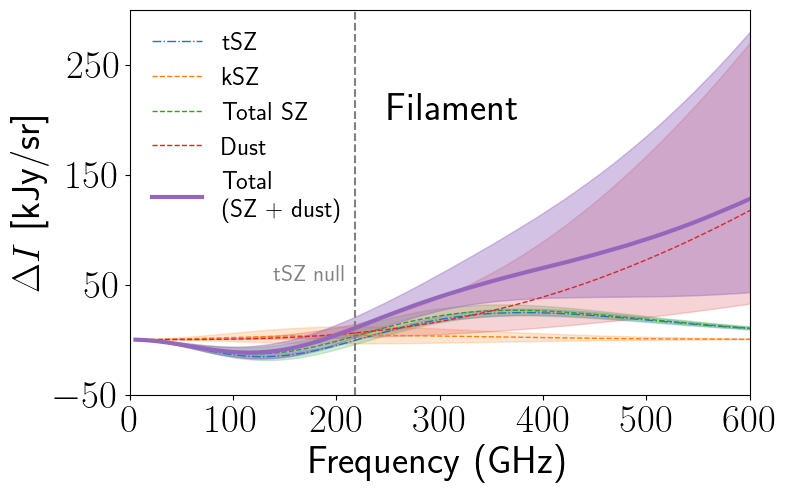

In [16]:
import matplotlib.ticker as ticker

plt.rc('text', usetex=True)
plt.rc('font', family='sans-serif', size=28)

fig = plt.figure(figsize=(8, 5))
ax1 = fig.add_subplot(111)

# Plot fil signals (filament) - blue for cluster 2
ax1.plot(SZ_params_fil_tSZ.nucmb, fil_signals_tSZ_mean, label='tSZ', color='C0', linestyle='-.', lw=1)
ax1.fill_between(SZ_params_fil_tSZ.nucmb, 
                 fil_signals_tSZ_percentile_16, 
                 fil_signals_tSZ_percentile_84,
                 color='C0', alpha=.2
                 )

ax1.plot(SZ_params_fil_kSZ.nucmb, fil_signals_kSZ_mean, label='kSZ', color='C1', linestyle='--', lw=1)
ax1.fill_between(SZ_params_fil_kSZ.nucmb,
                 fil_signals_kSZ_percentile_16,
                 fil_signals_kSZ_percentile_84,
                 color='C1', alpha=.2
                 )

ax1.plot(SZ_params_fil_kSZ.nucmb, fil_signals_total_sz_mean, label='Total SZ', color='C2', linestyle='--', lw=1)
ax1.fill_between(SZ_params_fil_kSZ.nucmb,
                 fil_signals_total_sz_percentile_16,
                 fil_signals_total_sz_percentile_84,
                 color='C2', alpha=.2
                 )

# plot dust signals
ax1.plot(SZ_params_fil_tSZ.nucmb, dust_fil_signals_mean, label='Dust', color='C3', linestyle='--', lw=1)
ax1.fill_between(SZ_params_fil_tSZ.nucmb,
                 dust_fil_signals_percentile_16,
                 dust_fil_signals_percentile_84,
                 color='C3', alpha=.2
                 )

ax1.plot(SZ_params_fil_tSZ.nucmb, fil_signals_total_mean, label='Total \n(SZ + dust)', color='C4', linestyle='-', lw=3)

ax1.fill_between(SZ_params_fil_tSZ.nucmb,
                 fil_signals_total_percentile_16,
                 fil_signals_total_percentile_84,
                 color='C4', alpha=0.4)

ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.set_xlabel(r'Dimensionless frequency, $x= h\nu/k_{\rm B}T_{\rm CMB}$')
ax1.set_ylabel('$\Delta I$ [kJy/sr]')
ax1.legend(fontsize=18, frameon=0, loc='upper left', ncol=1, edgecolor='black')

# plt.axhline(0, color='grey', linestyle='--', alpha=0.2)
plt.xlabel('Frequency (GHz)')
plt.xticks(np.arange(0, 1200, 200))
#plt.savefig("../plots/sz_spectrum_tSZ_kSZ_total.pdf", bbox_inches='tight', dpi=400)

# vertical line at freq = 218
plt.axvline(218, color='grey', linestyle='--')
plt.text(174, 50, 'tSZ null', color='grey', fontsize=16, ha='center', va='bottom')
plt.ylim(-50, 300)
plt.xlim(0, 600)
ax1.set_yticks(np.arange(-50, 301, 100))
ax1.set_xticks(np.arange(0, 601, 100))
plt.text(250, 200, "Filament")
# ax1.grid()
plt.savefig("../plots/sz_dust_spectrum_fil.pdf", bbox_inches='tight', dpi=400)
plt.show()


In [ ]:
# import matplotlib.ticker as ticker

# plt.rc('text', usetex=True)
# plt.rc('font', family='serif', size=32)

# fig = plt.figure(figsize=(12, 6))
# ax1 = fig.add_subplot(111)

# # Plot C1 signals (Abell 401) - blue for cluster 1
# ax1.plot(SZ_params_c2_tSZ.nucmb, c2_signals_tSZ_mean, label='Abell 399 (tSZ)', color='C0', linestyle='-.', lw=1)
# ax1.fill_between(SZ_params_c2_tSZ.nucmb, 
#                  c2_signals_tSZ_percentile_16, 
#                  c2_signals_tSZ_percentile_84,
#                  color='C0', alpha=0.2)

# ax1.plot(SZ_params_c2_kSZ.nucmb, c2_signals_kSZ_mean, label='Abell 399 (kSZ)', color='C1', linestyle='--', lw=1)
# ax1.fill_between(SZ_params_c2_kSZ.nucmb,
#                  c2_signals_kSZ_percentile_16,
#                  c2_signals_kSZ_percentile_84,
#                  color='C1', alpha=0.2)

# ax1.plot(SZ_params_c2_kSZ.nucmb, c2_signals_total_sz_mean, label='Abell 399 (total SZ)', color='C2', linestyle='--', lw=1)
# ax1.fill_between(SZ_params_c2_kSZ.nucmb,
#                  c2_signals_total_sz_percentile_16,
#                  c2_signals_total_sz_percentile_84,
#                  color='C2', alpha=0.4)

# # Plot C2 signals (Abell 399) - red for cluster 2
# #ax1.plot(SZ_params_c2_tSZ.nucmb, c2_signals_tSZ_mean, label='Abell 399 (tSZ)', color='red', linestyle=':', lw=1)
# # ax1.fill_between(SZ_params_c2_tSZ.nucmb,
# #                  c2_signals_tSZ_percentile_16,
# #                  c2_signals_tSZ_percentile_84,
# #                  color='red', alpha=0.2)

# #ax1.plot(SZ_params_c2_kSZ.nucmb, c2_signals_kSZ_mean, label='Abell 399 (kSZ)', color='lightcoral', linestyle='--', lw=2)
# # ax1.fill_between(SZ_params_c2_kSZ.nucmb,
# #                  c2_signals_kSZ_percentile_16,
# #                  c2_signals_kSZ_percentile_84,
# #                  color='lightcoral', alpha=0.2)

# #ax1.plot(SZ_params_c2_total.nucmb, c2_signals_total_sz_mean, label='Abell 399 (total SZ)', color='darkred', linestyle='-', lw=3)
# # ax1.fill_between(SZ_params_c2_total.nucmb,
# #                  c2_signals_total_sz_percentile_16,
# #                  c2_signals_total_sz_percentile_84,
# #                  color='darkred', alpha=0.2)

# # Plot Filament signals - green for filament
# #ax1.plot(SZ_params_fil_tSZ.nucmb, fil_signals_tSZ_mean, label='Filament (tSZ)', color='green', linestyle=':', lw=2)
# # ax1.fill_between(SZ_params_fil_tSZ.nucmb,
# #                  fil_signals_tSZ_percentile_16,
# #                  fil_signals_tSZ_percentile_84,
# #                  color='green', alpha=0.2)

# #ax1.plot(SZ_params_fil_kSZ.nucmb, fil_signals_kSZ_mean, label='Filament (kSZ)', color='lightgreen', linestyle='--', lw=2)
# # ax1.fill_between(SZ_params_fil_kSZ.nucmb,
# #                  fil_signals_kSZ_percentile_16,
# #                  fil_signals_kSZ_percentile_84,
# #                  color='lightgreen', alpha=0.2)

# #ax1.plot(SZ_params_fil_total.nucmb, fil_signals_total_sz_mean, label='Filament (total SZ)', color='darkgreen', linestyle='-', lw=3)
# # ax1.fill_between(SZ_params_fil_total.nucmb,
# #                  fil_signals_total_sz_percentile_16,
# #                  fil_signals_total_sz_percentile_84,
# #                  color='darkgreen', alpha=0.2)

# # plot dust signals
# # ax1.plot(SZ_params_c1_tSZ.nucmb, dust_c1_signals_mean, label='Abell 401 (dust)', color='C3', linestyle='--', lw=1)
# # ax1.fill_between(SZ_params_c1_tSZ.nucmb,
# #                  dust_c1_signals_percentile_16,
# #                  dust_c1_signals_percentile_84,
# #                  color='C3', alpha=0.2)

# #ax1.plot(SZ_params_fil_total.nucmb, dust_c2_signals_mean, label='Dust (C2)', color='red', linestyle='-.', lw=2)
# # ax1.fill_between(SZ_params_fil_total.nucmb,
# #                  dust_c2_signals_percentile_16,
# #                  dust_c2_signals_percentile_84,
# #                  color='gold', alpha=0.2)

# #ax1.plot(SZ_params_fil_total.nucmb, dust_fil_signals_mean, label='Dust (Filament)', color='green', linestyle='-.', lw=3)
# # ax1.fill_between(SZ_params_fil_total.nucmb,
# #                  dust_fil_signals_percentile_16,
# #                  dust_fil_signals_percentile_84,
# #                  color='darkorange', alpha=0.2)

# # Plot total signals
# # ax1.plot(SZ_params_c1_tSZ.nucmb, c1_signals_total_mean, label='Abell 401 (total)', color='C4', linestyle='-', lw=3)
# #ax1.plot(SZ_params_c1_tSZ.nucmb, c2_signals_total_mean, label='Abell 399 (total)', color='red', linestyle=':', lw=2)
# #ax1.plot(SZ_params_fil_total.nucmb, fil_signals_total_mean, label='Fil (total)', color='green', linestyle=':', lw=2)

# # ax1.fill_between(SZ_params_c1_tSZ.nucmb,
# #                  c1_signals_total_percentile_16,
# #                  c1_signals_total_percentile_84,
# #                  color='C4', alpha=0.2)

# ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
# ax1.set_xlabel(r'Dimensionless frequency, $x= h\nu/k_{\rm B}T_{\rm CMB}$')
# ax1.set_ylabel('$\Delta I$ [kJy/Sr]')
# ax1.legend(fontsize=20, frameon=0, loc='upper right', ncol=3, bbox_to_anchor=(1, 1.3))

# plt.axhline(0, color='grey', linestyle='--')
# plt.xlabel('Frequency (GHz)')
# plt.xticks(np.arange(0, 1200, 200))
# #plt.savefig("../plots/sz_spectrum_tSZ_kSZ_total.pdf", bbox_inches='tight', dpi=400)

# # vertical line at freq = 218
# plt.axvline(220, color='grey', linestyle='--')
# plt.ylim(-190, 220)
# plt.xlim(0, 700)
# ax1.set_yticks(np.arange(-200, 201, 50))
# ax1.grid()
# plt.show()


In [ ]:
# Calculate correlation at each frequency point for A401
correlations_tsz_ksz = []
correlations_tsz_dust = []
correlations_ksz_dust = []
correlations_total_sz_dust = []
correlations_total_signal_dust = []
correlations_total_signal_total_sz = []
frequencies = SZ_params_c1_tSZ.nucmb  # Your frequency array

for freq_idx in range(len(frequencies)):
    # Get the tSZ, kSZ, dust and total signals at this frequency for all MCMC samples
    tsz_vector = c1_signals_tSZ_stacked[:, freq_idx]  
    ksz_vector = c1_signals_kSZ_stacked[:, freq_idx]
    dust_vector = dust_c1_signals_stacked[:, freq_idx]
    total_sz_vector = c1_signals_total_sz_stacked[:, freq_idx]
    total_signal_vector = c1_signals_total_stacked[:, freq_idx]
    
    # Calculate Pearson correlation coefficients
    if np.std(tsz_vector) > 0 and np.std(ksz_vector) > 0:
        corr_tsz_ksz = np.corrcoef(tsz_vector, ksz_vector)[0,1]
    else:
        corr_tsz_ksz = 0
        
    if np.std(tsz_vector) > 0 and np.std(dust_vector) > 0:
        corr_tsz_dust = np.corrcoef(tsz_vector, dust_vector)[0,1]
    else:
        corr_tsz_dust = 0
        
    if np.std(ksz_vector) > 0 and np.std(dust_vector) > 0:
        corr_ksz_dust = np.corrcoef(ksz_vector, dust_vector)[0,1]
    else:
        corr_ksz_dust = 0
        
    if np.std(total_sz_vector) > 0 and np.std(dust_vector) > 0:
        corr_total_sz_dust = np.corrcoef(total_sz_vector, dust_vector)[0,1]
    else:
        corr_total_sz_dust = 0
        
    if np.std(total_signal_vector) > 0 and np.std(dust_vector) > 0:
        corr_total_signal_dust = np.corrcoef(total_signal_vector, dust_vector)[0,1]
    else:
        corr_total_signal_dust = 0
        
    if np.std(total_signal_vector) > 0 and np.std(total_sz_vector) > 0:
        corr_total_signal_total_sz = np.corrcoef(total_signal_vector, total_sz_vector)[0,1]
    else:
        corr_total_signal_total_sz = 0
    
    correlations_tsz_ksz.append(corr_tsz_ksz)
    correlations_tsz_dust.append(corr_tsz_dust)
    correlations_ksz_dust.append(corr_ksz_dust)
    correlations_total_sz_dust.append(corr_total_sz_dust)
    correlations_total_signal_dust.append(corr_total_signal_dust)
    correlations_total_signal_total_sz.append(corr_total_signal_total_sz)

# Create five separate plots with more space
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

# Plot 1: tSZ-kSZ correlation
axes[0].plot(frequencies, correlations_tsz_ksz, 'b-', linewidth=2, label='tSZ-kSZ correlation')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[0].axvline(x=217, color='red', linestyle='--', alpha=0.5, label='217 GHz (tSZ null)')
axes[0].set_xlabel('Frequency (GHz)', fontsize=12)
axes[0].set_ylabel('Correlation Coefficient', fontsize=12)
axes[0].set_title('tSZ vs kSZ Correlation (A401)', fontsize=14)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_ylim(-1.1, 1.1)
axes[0].set_xlim(0, 600)

# Plot 2: tSZ-dust correlation
axes[1].plot(frequencies, correlations_tsz_dust, 'g-', linewidth=2, label='tSZ-dust correlation')
axes[1].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[1].axvline(x=217, color='red', linestyle='--', alpha=0.5, label='217 GHz (tSZ null)')
axes[1].set_xlabel('Frequency (GHz)', fontsize=12)
axes[1].set_ylabel('Correlation Coefficient', fontsize=12)
axes[1].set_title('tSZ vs Dust Correlation (A401)', fontsize=14)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(-1.1, 1.1)
axes[1].set_xlim(0, 600)

# Plot 3: kSZ-dust correlation
axes[2].plot(frequencies, correlations_ksz_dust, 'r-', linewidth=2, label='kSZ-dust correlation')
axes[2].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[2].axvline(x=217, color='red', linestyle='--', alpha=0.5, label='217 GHz (tSZ null)')
axes[2].set_xlabel('Frequency (GHz)', fontsize=12)
axes[2].set_ylabel('Correlation Coefficient', fontsize=12)
axes[2].set_title('kSZ vs Dust Correlation (A401)', fontsize=14)
axes[2].legend(fontsize=10)
axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(-1.1, 1.1)
axes[2].set_xlim(0, 600)

# Plot 4: total SZ-dust correlation
axes[3].plot(frequencies, correlations_total_sz_dust, 'm-', linewidth=2, label='Total SZ-dust correlation')
axes[3].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[3].axvline(x=217, color='red', linestyle='--', alpha=0.5, label='217 GHz (tSZ null)')
axes[3].set_xlabel('Frequency (GHz)', fontsize=12)
axes[3].set_ylabel('Correlation Coefficient', fontsize=12)
axes[3].set_title('Total SZ vs Dust Correlation (A401)', fontsize=14)
axes[3].legend(fontsize=10)
axes[3].grid(True, alpha=0.3)
axes[3].set_ylim(-1.1, 1.1)
axes[3].set_xlim(0, 600)

# Plot 5: total signal-dust correlation
axes[4].plot(frequencies, correlations_total_signal_dust, 'c-', linewidth=2, label='Total signal-dust correlation')
axes[4].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[4].axvline(x=217, color='red', linestyle='--', alpha=0.5, label='217 GHz (tSZ null)')
axes[4].set_xlabel('Frequency (GHz)', fontsize=12)
axes[4].set_ylabel('Correlation Coefficient', fontsize=12)
axes[4].set_title('Total Signal vs Dust Correlation (A401)', fontsize=14)
axes[4].legend(fontsize=10)
axes[4].grid(True, alpha=0.3)
axes[4].set_ylim(-1.1, 1.1)
axes[4].set_xlim(0, 600)

# Plot 6: total signal-total SZ correlation
axes[5].plot(frequencies, correlations_total_signal_total_sz, 'orange', linewidth=2, label='Total signal-total SZ correlation')
axes[5].axhline(y=0, color='gray', linestyle='--', alpha=0.5)
axes[5].axvline(x=217, color='red', linestyle='--', alpha=0.5, label='217 GHz (tSZ null)')
axes[5].set_xlabel('Frequency (GHz)', fontsize=12)
axes[5].set_ylabel('Correlation Coefficient', fontsize=12)
axes[5].set_title('Total Signal vs Total SZ Correlation (A401)', fontsize=14)
axes[5].legend(fontsize=10)
axes[5].grid(True, alpha=0.3)
axes[5].set_ylim(-1.1, 1.1)
axes[5].set_xlim(0, 600)

plt.tight_layout()
plt.show()

# Print some diagnostic info
print(f"tSZ-kSZ correlation - Mean: {np.mean(correlations_tsz_ksz):.3f}")
print(f"tSZ-dust correlation - Mean: {np.mean(correlations_tsz_dust):.3f}")
print(f"kSZ-dust correlation - Mean: {np.mean(correlations_ksz_dust):.3f}")
print(f"Total SZ-dust correlation - Mean: {np.mean(correlations_total_sz_dust):.3f}")
print(f"Total signal-dust correlation - Mean: {np.mean(correlations_total_signal_dust):.3f}")
print(f"Total signal-total SZ correlation - Mean: {np.mean(correlations_total_signal_total_sz):.3f}")

# Also check the correlation between tau and velocity in your MCMC chain
tau_samples = samples[:, 6]
v_samples = samples[:, 9]
dust_samples = samples[:, 8]
tau_v_corr = np.corrcoef(tau_samples, v_samples)[0,1]
tau_dust_corr = np.corrcoef(tau_samples, dust_samples)[0,1]
v_dust_corr = np.corrcoef(v_samples, dust_samples)[0,1]

print(f"\nCorrelation between tau and velocity in MCMC: {tau_v_corr:.3f}")
print(f"Correlation between tau and dust in MCMC: {tau_dust_corr:.3f}")
print(f"Correlation between velocity and dust in MCMC: {v_dust_corr:.3f}")

# Check if the issue is in your parameter space
Te_samples = samples[:, 7]
tau_Te_corr = np.corrcoef(tau_samples, Te_samples)[0,1]
print(f"Correlation between tau and Te in MCMC: {tau_Te_corr:.3f}")

In [ ]:
# Calculate correlation at each frequency point
correlations = []
frequencies = SZ_params_c2_tSZ.nucmb  # Your frequency array

for freq_idx in range(len(frequencies)):
    # Get the tSZ and kSZ values at this frequency for all MCMC samples
    tsz_vector = c2_signals_tSZ_stacked[:, freq_idx]  
    ksz_vector = c2_signals_kSZ_stacked[:, freq_idx]  
    
    # Calculate Pearson correlation coefficient
    if np.std(tsz_vector) > 0 and np.std(ksz_vector) > 0:
        corr = np.corrcoef(tsz_vector, ksz_vector)[0,1]
    else:
        corr = 0  # Handle case where one signal has no variance
    
    correlations.append(corr)

# Plot the correlation vs frequency
plt.figure(figsize=(12, 6))
plt.plot(frequencies, correlations, 'b-', linewidth=2, label='tSZ-kSZ correlation')
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=217, color='red', linestyle='--', alpha=0.5, label='217 GHz (tSZ null)')
plt.xlabel('Frequency (GHz)', fontsize=14)
plt.ylabel('Correlation Coefficient', fontsize=14)
plt.title('Correlation between tSZ and kSZ signals vs Frequency', fontsize=16)
plt.legend()
plt.grid(True, alpha=0.3)
plt.ylim(-.5, .5)
plt.xlim(0, 500)
plt.show()

# Print some diagnostic info
print(f"Mean correlation: {np.mean(correlations):.3f}")
print(f"Correlation at 100 GHz: {correlations[50]:.3f}")  # Adjust index as needed
print(f"Correlation at 217 GHz: {correlations[110]:.3f}")  # Adjust index as needed
print(f"Correlation at 350 GHz: {correlations[200]:.3f}")  # Adjust index as needed

# Also check the correlation between tau and velocity in your MCMC chain
tau_samples = samples[:, 16]
v_samples = samples[:, 19]
tau_v_corr = np.corrcoef(tau_samples, v_samples)[0,1]
print(f"\nCorrelation between tau and velocity in MCMC: {tau_v_corr:.3f}")

# Check if the issue is in your parameter space
Te_samples = samples[:, 17]
tau_Te_corr = np.corrcoef(tau_samples, Te_samples)[0,1]
print(f"Correlation between tau and Te in MCMC: {tau_Te_corr:.3f}")

# Also check the correla

In [ ]:
import matplotlib.ticker as ticker

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=20)

fig = plt.figure(figsize=(12, 6))
ax1 = fig.add_subplot(111)

# Plot C2 signals (Abell 399) - blue for cluster 2
ax1.plot(SZ_params_c1_tSZ.nucmb, c1_signals_tSZ_mean, label='Abell 399 (tSZ)', color='C0', linestyle='-.', lw=1)
ax1.fill_between(SZ_params_c1_tSZ.nucmb, 
                 c1_signals_tSZ_percentile_16, 
                 c1_signals_tSZ_percentile_84,
                 color='C0', alpha=0.2)

ax1.plot(SZ_params_c1_kSZ.nucmb, c1_signals_kSZ_mean, label='Abell 399 (kSZ)', color='C1', linestyle='--', lw=1)
ax1.fill_between(SZ_params_c1_kSZ.nucmb,
                 c1_signals_kSZ_percentile_16,
                 c1_signals_kSZ_percentile_84,
                 color='C1', alpha=0.7)

ax1.plot(SZ_params_c1_total.nucmb, c1_signals_total_sz_mean, label='Abell 399 (total SZ)', color='c1', linestyle='--', lw=1)
ax1.fill_between(SZ_params_c1_total.nucmb,
                 c1_signals_total_sz_percentile_16,
                 c1_signals_total_sz_percentile_84,
                 color='C2', alpha=0.4)

# Plot C1 signals (Abell 401) - red for cluster 1
#ax1.plot(SZ_params_c1_tSZ.nucmb, c1_signals_tSZ_mean, label='Abell 401 (tSZ)', color='red', linestyle=':', lw=1)
# ax1.fill_between(SZ_params_c1_tSZ.nucmb,
#                  c1_signals_tSZ_percentile_16,
#                  c1_signals_tSZ_percentile_84,
#                  color='red', alpha=0.2)

#ax1.plot(SZ_params_c1_kSZ.nucmb, c1_signals_kSZ_mean, label='Abell 401 (kSZ)', color='lightcoral', linestyle='--', lw=2)
# ax1.fill_between(SZ_params_c1_kSZ.nucmb,
#                  c1_signals_kSZ_percentile_16,
#                  c1_signals_kSZ_percentile_84,
#                  color='lightcoral', alpha=0.2)

#ax1.plot(SZ_params_c1_total.nucmb, c1_signals_total_sz_mean, label='Abell 401 (total SZ)', color='darkred', linestyle='-', lw=3)
# ax1.fill_between(SZ_params_c1_total.nucmb,
#                  c1_signals_total_sz_percentile_16,
#                  c1_signals_total_sz_percentile_84,
#                  color='darkred', alpha=0.2)

# Plot Filament signals - green for filament
#ax1.plot(SZ_params_fil_tSZ.nucmb, fil_signals_tSZ_mean, label='Filament (tSZ)', color='green', linestyle=':', lw=2)
# ax1.fill_between(SZ_params_fil_tSZ.nucmb,
#                  fil_signals_tSZ_percentile_16,
#                  fil_signals_tSZ_percentile_84,
#                  color='green', alpha=0.2)

#ax1.plot(SZ_params_fil_kSZ.nucmb, fil_signals_kSZ_mean, label='Filament (kSZ)', color='lightgreen', linestyle='--', lw=2)
# ax1.fill_between(SZ_params_fil_kSZ.nucmb,
#                  fil_signals_kSZ_percentile_16,
#                  fil_signals_kSZ_percentile_84,
#                  color='lightgreen', alpha=0.2)

#ax1.plot(SZ_params_fil_total.nucmb, fil_signals_total_sz_mean, label='Filament (total SZ)', color='darkgreen', linestyle='-', lw=3)
# ax1.fill_between(SZ_params_fil_total.nucmb,
#                  fil_signals_total_sz_percentile_16,
#                  fil_signals_total_sz_percentile_84,
#                  color='darkgreen', alpha=0.2)

# plot dust signals
# ax1.plot(SZ_params_c2_tSZ.nucmb, dust_c2_signals_mean, label='Abell 399 (dust)', color='C3', linestyle='--', lw=1)
# ax1.fill_between(SZ_params_c2_tSZ.nucmb,
#                  dust_c2_signals_percentile_16,
#                  dust_c2_signals_percentile_84,
#                  color='C3', alpha=0.2)

#ax1.plot(SZ_params_fil_total.nucmb, dust_c2_signals_mean, label='Dust (C2)', color='red', linestyle='-.', lw=2)
# ax1.fill_between(SZ_params_fil_total.nucmb,
#                  dust_c2_signals_percentile_16,
#                  dust_c2_signals_percentile_84,
#                  color='gold', alpha=0.2)

#ax1.plot(SZ_params_fil_total.nucmb, dust_fil_signals_mean, label='Dust (Filament)', color='green', linestyle='-.', lw=3)
# ax1.fill_between(SZ_params_fil_total.nucmb,
#                  dust_fil_signals_percentile_16,
#                  dust_fil_signals_percentile_84,
#                  color='darkorange', alpha=0.2)

# Plot total signals
# ax1.plot(SZ_params_c2_tSZ.nucmb, c2_signals_total_mean, label='Abell 399 (total)', color='C4', linestyle='-', lw=3)
#ax1.plot(SZ_params_c1_tSZ.nucmb, c1_signals_total_mean, label='Abell 401 (total)', color='red', linestyle=':', lw=2)
#ax1.plot(SZ_params_fil_total.nucmb, fil_signals_total_mean, label='Fil (total)', color='green', linestyle=':', lw=2)

# ax1.fill_between(SZ_params_c2_tSZ.nucmb,
#                  c2_signals_total_percentile_16,
#                  c2_signals_total_percentile_84,
#                  color='C4', alpha=0.2)

ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.set_xlabel(r'Dimensionless frequency, $x= h\nu/k_{\rm B}T_{\rm CMB}$')
ax1.set_ylabel('$\Delta I$ [kJy/Sr]')
ax1.legend(fontsize=20, frameon=0, loc='upper right', ncol=3, bbox_to_anchor=(1, 1.3))

plt.axhline(0, color='grey', linestyle='--')
plt.xlabel('Frequency (GHz)')
plt.xticks(np.arange(0, 1200, 25))
#plt.savefig("../plots/sz_spectrum_tSZ_kSZ_total.pdf", bbox_inches='tight', dpi=400)

# vertical line at freq = 218
plt.axvline(220, color='grey', linestyle='--')
plt.ylim(-110, 70)
plt.xlim(0, 400)
ax1.set_yticks(np.arange(-120, 100, 20))
ax1.grid()
plt.show()


In [ ]:
# # Calculate correlation coefficient between tSZ and kSZ as a function of frequency
# correlations_across_samples = []
# frequencies = SZ_params_c1_tSZ.nucmb  # Frequency array

# # Method 1: Correlation across samples at each frequency
# for freq_idx in range(len(frequencies)):
#     tsz_at_freq = c1_signals_tSZ_stacked[:, freq_idx]
#     ksz_at_freq = c1_signals_kSZ_stacked[:, freq_idx]
    
#     correlation = np.corrcoef(tsz_at_freq, ksz_at_freq)[0, 1]
#     correlations_across_samples.append(correlation)

# correlations_across_samples = np.array(correlations_across_samples)

# # Method 2: Direct correlation between mean signals across frequency
# correlation_means = np.corrcoef(c1_signals_tSZ_mean, c1_signals_kSZ_mean)[0, 1]

# # Plot both analyses
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# # Plot 1: Correlation vs frequency (across samples)
# ax1.plot(frequencies, correlations_across_samples, 'b-', linewidth=2, label='tSZ-kSZ correlation')
# ax1.axhline(0, color='black', linestyle='--', alpha=0.5)
# ax1.set_xlabel('Frequency (GHz)')
# ax1.set_ylabel('Correlation Coefficient')
# ax1.set_title('Correlation between tSZ and kSZ signals vs Frequency\n(across MCMC samples)')
# ax1.grid(True, alpha=0.3)
# ax1.legend()
# ax1.set_xlim(0, 700)
# ax1.set_ylim(-1, 1)

# # Plot 2: Mean signals correlation (scatter plot)
# ax2.scatter(c1_signals_tSZ_mean, c1_signals_kSZ_mean, alpha=0.6, c=frequencies, cmap='viridis', s=20)
# ax2.set_xlabel('tSZ Mean Signal [kJy/sr]')
# ax2.set_ylabel('kSZ Mean Signal [kJy/sr]')
# ax2.set_title(f'tSZ vs kSZ Mean Signals\n(correlation = {correlation_means:.3f})')
# ax2.grid(True, alpha=0.3)
# cbar = plt.colorbar(ax2.collections[0], ax=ax2)
# cbar.set_label('Frequency (GHz)')

# # Add frequency annotations for specific points to show precision
# # Add more frequency annotations with better spacing
# # Get valid frequency indices that exist in the array
# valid_freq_indices = []
# target_freqs = [50, 90, 100, 125, 150, 200, 218, 250, 300, 350, 400, 500, 600]

# for target_freq in target_freqs:
#     # Find the closest frequency index
#     closest_idx = np.argmin(np.abs(frequencies - target_freq))
#     if frequencies[closest_idx] <= 700:  # Only include if within reasonable range
#         valid_freq_indices.append(closest_idx)

# # Add first and last indices
# valid_freq_indices = [0] + valid_freq_indices + [-1]
# valid_freq_indices = list(set(valid_freq_indices))  # Remove duplicates
# valid_freq_indices.sort()

# # Annotate the valid points
# for idx in valid_freq_indices[::2]:  # Use every other point to avoid overcrowding
#     ax2.annotate(f'{frequencies[idx]:.0f} GHz', 
#                 xy=(c1_signals_tSZ_mean[idx], c1_signals_kSZ_mean[idx]),
#                 xytext=(5, 5), textcoords='offset points',
#                 fontsize=8, alpha=0.7,
#                 bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

# plt.tight_layout()
# plt.show()

# print(f"Correlation across samples - Mean: {np.mean(correlations_across_samples):.3f}")
# print(f"Correlation across samples - Range: [{np.min(correlations_across_samples):.3f}, {np.max(correlations_across_samples):.3f}]")
# print(f"Frequency range: {frequencies[0]:.2f} - {frequencies[-1]:.2f} GHz")
# print(f"Number of frequency points: {len(frequencies)}")
# print(f"Correlation between mean signals: {correlation_means:.3f}")

In [ ]:
np.corrcoef(c1_signals_kSZ_mean, c1_signals_tSZ_mean).shape

In [ ]:
SZ_params_c2_tSZ.nucmb

In [ ]:
# plot the difference between the 84 and 16 percentile as a function of frequency
# c1_uncertainty = c1_signals_total_percentile_84 - c1_signals_total_percentile_16
c1_ksz_uncertainty = c1_signals_kSZ_percentile_84 - c1_signals_kSZ_percentile_16
c1_tsz_uncertainty = c1_signals_tSZ_percentile_84 - c1_signals_tSZ_percentile_16
c1_dust_uncertainty = dust_c1_signals_percentile_84 - dust_c1_signals_percentile_16
c1_total_uncertainty = c1_signals_total_sz_percentile_84 - c1_signals_total_sz_percentile_16

plt.figure(figsize=(10, 6))
# plt.plot(SZ_params_c1_total.nucmb, c1_uncertainty, 'b-', linewidth=2, label='Abell 401 total uncertainty')
plt.plot(SZ_params_c1_kSZ.nucmb, c1_ksz_uncertainty, 'r-', linewidth=2, label='Abell 401 kSZ uncertainty')
plt.plot(SZ_params_c1_tSZ.nucmb, c1_tsz_uncertainty, 'g-', linewidth=2, label='Abell 401 tSZ uncertainty')
# plt.plot(SZ_params_c1_tSZ.nucmb, c1_dust_uncertainty, 'm-', linewidth=2, label='Abell 401 dust uncertainty')
plt.plot(SZ_params_c1_tSZ.nucmb, c1_total_uncertainty, 'k-', linewidth=2, label='Abell 401 total SZ uncertainty')

plt.xlabel('Frequency (GHz)')
plt.ylabel('Uncertainty (84th - 16th percentile) [kJy/sr]')
plt.title('SZ Signal Uncertainty vs Frequency for Abell 401')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)
plt.ylim(0, 60)
plt.xlim(0, 700)
plt.show()

# plot for C2
# c2_uncertainty = c2_signals_total_percentile_84 - c2_signals_total_percentile_16
# c2_ksz_uncertainty = c2_signals_kSZ_percentile_84 - c2_signals_kSZ_percentile_16
# c2_tsz_uncertainty = c2_signals_tSZ_percentile_84 - c2_signals_tSZ_percentile_16
# c2_dust_uncertainty = dust_c2_signals_percentile_84 - dust_c2_signals_percentile_16
# c2_total_uncertainty = c2_signals_total_sz_percentile_84 - c2_signals_total_sz_percentile_16

# plt.figure(figsize=(10, 6))
# # plt.plot(SZ_params_c2_total.nucmb, c2_uncertainty, 'b-', linewidth=2, label='Abell 399 total uncertainty')
# plt.plot(SZ_params_c2_kSZ.nucmb, c2_ksz_uncertainty, 'r-', linewidth=2, label='Abell 399 kSZ uncertainty')
# plt.plot(SZ_params_c2_tSZ.nucmb, c2_tsz_uncertainty, 'g-', linewidth=2, label='Abell 399 tSZ uncertainty')
# # plt.plot(SZ_params_c2_tSZ.nucmb, c2_dust_uncertainty, 'm-', linewidth=2, label='Abell 399 dust uncertainty')
# plt.plot(SZ_params_c2_tSZ.nucmb, c2_total_uncertainty, 'k-', linewidth=2, label='Abell 399 total SZ uncertainty')

# plt.xlabel('Frequency (GHz)')
# plt.ylabel('Uncertainty (84th - 16th percentile) [kJy/sr]')
# plt.title('SZ Signal Uncertainty vs Frequency for Abell 399')

# plt.grid(True, alpha=0.3)
# plt.legend(fontsize=12)
# plt.ylim(0, 60)
# plt.xlim(0, 700)

In [ ]:
# # process dust signals
# dust_c1_signals_stacked = np.stack(c1_signals_dust) / 1000
# dust_c1_signals_percentile_16 = np.percentile(dust_c1_signals_stacked, 16, axis=0)
# dust_c1_signals_percentile_84 = np.percentile(dust_c1_signals_stacked, 84, axis=0)
# dust_c1_signals_mean = np.mean(dust_c1_signals_stacked, axis=0)

# dust_c2_signals_stacked = np.stack(dust_c2_signals) / 1000
# dust_c2_signals_percentile_16 = np.percentile(dust_c2_signals_stacked, 16, axis=0)
# dust_c2_signals_percentile_84 = np.percentile(dust_c2_signals_stacked, 84, axis=0)
# dust_c2_signals_mean = np.mean(dust_c2_signals_stacked, axis=0)

# dust_fil_signals_stacked = np.stack(dust_fil_signals) / 1000
# dust_fil_signals_percentile_16 = np.percentile(dust_fil_signals_stacked, 16, axis=0)
# dust_fil_signals_percentile_84 = np.percentile(dust_fil_signals_stacked, 84, axis=0)
# dust_fil_signals_mean = np.mean(dust_fil_signals_stacked, axis=0)

# # Process tSZ signals
# c1_signals_tSZ_stacked = np.stack(c1_signals_tSZ) / 1000
# c1_signals_tSZ_percentile_16 = np.percentile(c1_signals_tSZ_stacked, 16, axis=0)
# c1_signals_tSZ_percentile_84 = np.percentile(c1_signals_tSZ_stacked, 84, axis=0)
# c1_signals_tSZ_mean = np.median(c1_signals_tSZ_stacked, axis=0)

# c2_signals_tSZ_stacked = np.stack(c2_signals_tSZ) / 1000
# c2_signals_tSZ_percentile_16 = np.percentile(c2_signals_tSZ_stacked, 16, axis=0)
# c2_signals_tSZ_percentile_84 = np.percentile(c2_signals_tSZ_stacked, 84, axis=0)
# c2_signals_tSZ_mean = np.median(c2_signals_tSZ_stacked, axis=0)

# fil_signals_tSZ_stacked = np.stack(fil_signals_tSZ) / 1000
# fil_signals_tSZ_percentile_16 = np.percentile(fil_signals_tSZ_stacked, 16, axis=0)
# fil_signals_tSZ_percentile_84 = np.percentile(fil_signals_tSZ_stacked, 84, axis=0)
# fil_signals_tSZ_mean = np.median(fil_signals_tSZ_stacked, axis=0)

# # Process kSZ signals
# c1_signals_kSZ_stacked = np.stack(c1_signals_kSZ) / 1000
# c1_signals_kSZ_percentile_16 = np.percentile(c1_signals_kSZ_stacked, 16, axis=0)
# c1_signals_kSZ_percentile_84 = np.percentile(c1_signals_kSZ_stacked, 84, axis=0)
# c1_signals_kSZ_mean = np.median(c1_signals_kSZ_stacked, axis=0)

# c2_signals_kSZ_stacked = np.stack(c2_signals_kSZ) / 1000
# c2_signals_kSZ_percentile_16 = np.percentile(c2_signals_kSZ_stacked, 16, axis=0)
# c2_signals_kSZ_percentile_84 = np.percentile(c2_signals_kSZ_stacked, 84, axis=0)
# c2_signals_kSZ_mean = np.median(c2_signals_kSZ_stacked, axis=0)

# fil_signals_kSZ_stacked = np.stack(fil_signals_kSZ) / 1000
# fil_signals_kSZ_percentile_16 = np.percentile(fil_signals_kSZ_stacked, 16, axis=0)
# fil_signals_kSZ_percentile_84 = np.percentile(fil_signals_kSZ_stacked, 84, axis=0)
# fil_signals_kSZ_mean = np.median(fil_signals_kSZ_stacked, axis=0)

# # Process total SZ signals (tSZ + kSZ)
# c1_signals_total_sz_stacked = np.stack(c1_signals_total_sz) / 1000
# c1_signals_total_sz_percentile_16 = np.percentile(c1_signals_total_sz_stacked, 16, axis=0)
# c1_signals_total_sz_percentile_84 = np.percentile(c1_signals_total_sz_stacked, 84, axis=0)
# c1_signals_total_sz_mean = np.median(c1_signals_total_sz_stacked, axis=0)

# c2_signals_total_sz_stacked = np.stack(c2_signals_total_sz) / 1000
# c2_signals_total_sz_percentile_16 = np.percentile(c2_signals_total_sz_stacked, 16, axis=0)
# c2_signals_total_sz_percentile_84 = np.percentile(c2_signals_total_sz_stacked, 84, axis=0)
# c2_signals_total_sz_mean = np.median(c2_signals_total_sz_stacked, axis=0)

# fil_signals_total_sz_stacked = np.stack(fil_signals_total_sz) / 1000
# fil_signals_total_sz_percentile_16 = np.percentile(fil_signals_total_sz_stacked, 16, axis=0)
# fil_signals_total_sz_percentile_84 = np.percentile(fil_signals_total_sz_stacked, 84, axis=0)
# fil_signals_total_sz_mean = np.median(fil_signals_total_sz_stacked, axis=0)

# # Process total (SZ + dust)
# c1_signals_total_stacked = np.stack(c1_signals_total) / 1000
# c1_signals_total_percentile_16 = np.percentile(c1_signals_total_stacked, 16, axis=0)
# c1_signals_total_percentile_84 = np.percentile(c1_signals_total_stacked, 84, axis=0)
# c1_signals_total_mean = np.median(c1_signals_total_stacked, axis=0)

# c2_signals_total_stacked = np.stack(c2_signals_total) / 1000
# c2_signals_total_percentile_16 = np.percentile(c2_signals_total_stacked, 16, axis=0)
# c2_signals_total_percentile_84 = np.percentile(c2_signals_total_stacked, 84, axis=0)
# c2_signals_total_mean = np.median(c2_signals_total_stacked, axis=0)

# fil_signals_total_stacked = np.stack(fil_signals_total) / 1000
# fil_signals_total_percentile_16 = np.percentile(fil_signals_total_stacked, 16, axis=0)
# fil_signals_total_percentile_84 = np.percentile(fil_signals_total_stacked, 84, axis=0)
# fil_signals_total_mean = np.median(fil_signals_total_stacked, axis=0)

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import numpy as np

# ---------------- Palette (Okabe–Ito, colorblind-safe) ----------------
COL = {
    "c1": "#0072B2",   # Abell 401 (blue)
    "c2": "#D55E00",   # Abell 399 (vermillion/red)
    "fil": "#009E73",  # Filament (green)
}
LS = {"tSZ": ":", "kSZ": "--", "total": "-"}
LW = {"tSZ": 2.0, "kSZ": 2.0, "total": 3.0}
ALPHA_FILL = 0.16

# ---------------- Matplotlib style ----------------
mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 26,
    "axes.unicode_minus": False,  # pretty minus sign
})

fig, ax1 = plt.subplots(figsize=(12.5, 6.5))

# ---------- helper wrappers ----------
def band(x, lo, hi, color, z=1):
    ax1.fill_between(x, lo, hi, color=color, alpha=ALPHA_FILL, linewidth=0, zorder=z)

def line(x, y, color, style, width, lab=None, z=3):
    ax1.plot(x, y, color=color, linestyle=style, linewidth=width, label=lab, zorder=z)

# ================== A401 (blue) ==================
# tSZ
band(SZ_params_c1_tSZ.nucmb, c1_signals_tSZ_percentile_16, c1_signals_tSZ_percentile_84, COL["c1"])
line(SZ_params_c1_tSZ.nucmb, c1_signals_tSZ_mean, COL["c1"], LS["tSZ"], LW["tSZ"])
# kSZ
band(SZ_params_c1_kSZ.nucmb, c1_signals_kSZ_percentile_16, c1_signals_kSZ_percentile_84, COL["c1"])
line(SZ_params_c1_kSZ.nucmb, c1_signals_kSZ_mean, COL["c1"], LS["kSZ"], LW["kSZ"])
# total
band(SZ_params_c1_total.nucmb, c1_signals_total_percentile_16, c1_signals_total_percentile_84, COL["c1"])
line(SZ_params_c1_total.nucmb, c1_signals_total_mean, COL["c1"], LS["total"], LW["total"])

# ================== A399 (vermillion) ==================
band(SZ_params_c2_tSZ.nucmb, c2_signals_tSZ_percentile_16, c2_signals_tSZ_percentile_84, COL["c2"])
line(SZ_params_c2_tSZ.nucmb, c2_signals_tSZ_mean, COL["c2"], LS["tSZ"], LW["tSZ"])

band(SZ_params_c2_kSZ.nucmb, c2_signals_kSZ_percentile_16, c2_signals_kSZ_percentile_84, COL["c2"])
line(SZ_params_c2_kSZ.nucmb, c2_signals_kSZ_mean, COL["c2"], LS["kSZ"], LW["kSZ"])

band(SZ_params_c2_total.nucmb, c2_signals_total_percentile_16, c2_signals_total_percentile_84, COL["c2"])
line(SZ_params_c2_total.nucmb, c2_signals_total_mean, COL["c2"], LS["total"], LW["total"])

# ================== Filament (green) ==================
band(SZ_params_fil_tSZ.nucmb, fil_signals_tSZ_percentile_16, fil_signals_tSZ_percentile_84, COL["fil"])
line(SZ_params_fil_tSZ.nucmb, fil_signals_tSZ_mean, COL["fil"], LS["tSZ"], LW["tSZ"])

band(SZ_params_fil_kSZ.nucmb, fil_signals_kSZ_percentile_16, fil_signals_kSZ_percentile_84, COL["fil"])
line(SZ_params_fil_kSZ.nucmb, fil_signals_kSZ_mean, COL["fil"], LS["kSZ"], LW["kSZ"])

band(SZ_params_fil_total.nucmb, fil_signals_total_percentile_16, fil_signals_total_percentile_84, COL["fil"])
line(SZ_params_fil_total.nucmb, fil_signals_total_mean, COL["fil"], LS["total"], LW["total"])

# ---------------- Axes polish ----------------
ax1.set_xlabel(r"Frequency (GHz)")
ax1.set_ylabel(r"$\Delta I$ [kJy/Sr]")
ax1.set_xlim(0, 900)
ax1.set_ylim(-180, 220)
ax1.set_xticks(np.arange(0, 901, 200))
ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.minorticks_on()
ax1.grid(which="major", axis="x", linestyle=":", color="lightgrey", alpha=0.6)
ax1.spines["top"].set_visible(False)
ax1.spines["right"].set_visible(False)

# tSZ null (annotated)
ax1.axvline(218, color="grey", linestyle="--", lw=1)
ax1.text(222, 148, r"$\nu_{\rm null}$", color="grey", fontsize=18, va="bottom")

# ---------------- Two legends ----------------
# Legend 1: Objects (colors)
handles_objects = [
    Line2D([0], [0], color=COL["c1"], lw=3, linestyle="-", label="Abell 401"),
    Line2D([0], [0], color=COL["c2"], lw=3, linestyle="-", label="Abell 399"),
    Line2D([0], [0], color=COL["fil"], lw=3, linestyle="-", label="Filament"),
]
leg1 = ax1.legend(handles=handles_objects, loc="upper right", frameon=False, fontsize=18)

# Legend 2: Components (linestyles)
handles_comp = [
    Line2D([0], [0], color="black", lw=2, linestyle=LS["tSZ"], label="tSZ"),
    Line2D([0], [0], color="black", lw=2, linestyle=LS["kSZ"], label="kSZ"),
    Line2D([0], [0], color="black", lw=3, linestyle=LS["total"], label="Total"),
]
ax1.legend(handles=handles_comp, loc="upper center", ncol=3, frameon=False, fontsize=18)
ax1.add_artist(leg1)  # keep both legends

plt.tight_layout()
# When saving: rasterize fills to keep PDF small
# for coll in ax1.collections: coll.set_rasterized(True)
# plt.savefig("sz_spectrum_tSZ_kSZ_total.pdf", bbox_inches="tight", dpi=400)
plt.show()


In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import numpy as np

# ---------- colors (Okabe–Ito: colorblind-safe) ----------
COL = {
    "c1":  "#0072B2",  # Abell 401 (blue)
    "c2":  "#D55E00",  # Abell 399 (vermillion/red)
    "fil": "#009E73",  # Filament (green)
}
LS = {"tSZ": ":", "kSZ": "--", "total": "-"}
LW = {"tSZ": 2.0, "kSZ": 2.0, "total": 3.0}

# ribbon style
ALPHA_FILL = 0.1         # softer fills (less overlap)
EDGE_LW    = 1.1          # thin outline for the bands

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.size": 26,
    #"axes.unicode_minus": False,
})

fig, ax1 = plt.subplots(figsize=(12, 6.5))

# ---------- helpers ----------
def band_outlined(x, lo, hi, color, z=1):
    ax1.fill_between(
        x, lo, hi,
        facecolor=color, alpha=ALPHA_FILL,
        edgecolor=color, linewidth=EDGE_LW,
        zorder=z
    )

def line_with_outline(x, y, color, ls, lw, z=4):
    # white under-stroke separates line from overlapping ribbons behind it
    ax1.plot(x, y, color="white", linestyle=ls, linewidth=lw+2.2, zorder=z)
    ax1.plot(x, y, color=color,  linestyle=ls, linewidth=lw,      zorder=z+0.1)

# ===== Abell 401 (blue) =====
# draw bands first (tSZ / kSZ behind total), then lines with outlines
band_outlined(SZ_params_c1_tSZ.nucmb,   c1_signals_tSZ_percentile_16,   c1_signals_tSZ_percentile_84,   COL["c1"], z=0.6)
band_outlined(SZ_params_c1_kSZ.nucmb,   c1_signals_kSZ_percentile_16,   c1_signals_kSZ_percentile_84,   COL["c1"], z=0.7)
band_outlined(SZ_params_c1_total.nucmb, c1_signals_total_percentile_16, c1_signals_total_percentile_84, COL["c1"], z=0.8)

line_with_outline(SZ_params_c1_tSZ.nucmb,   c1_signals_tSZ_mean,   COL["c1"], LS["tSZ"],   LW["tSZ"],   z=3.0)
line_with_outline(SZ_params_c1_kSZ.nucmb,   c1_signals_kSZ_mean,   COL["c1"], LS["kSZ"],   LW["kSZ"],   z=3.1)
line_with_outline(SZ_params_c1_total.nucmb, c1_signals_total_mean, COL["c1"], LS["total"], LW["total"], z=3.2)

# ===== Abell 399 (vermillion/red) =====
band_outlined(SZ_params_c2_tSZ.nucmb,   c2_signals_tSZ_percentile_16,   c2_signals_tSZ_percentile_84,   COL["c2"], z=0.6)
band_outlined(SZ_params_c2_kSZ.nucmb,   c2_signals_kSZ_percentile_16,   c2_signals_kSZ_percentile_84,   COL["c2"], z=0.7)
band_outlined(SZ_params_c2_total.nucmb, c2_signals_total_percentile_16, c2_signals_total_percentile_84, COL["c2"], z=0.8)

line_with_outline(SZ_params_c2_tSZ.nucmb,   c2_signals_tSZ_mean,   COL["c2"], LS["tSZ"],   LW["tSZ"],   z=3.0)
line_with_outline(SZ_params_c2_kSZ.nucmb,   c2_signals_kSZ_mean,   COL["c2"], LS["kSZ"],   LW["kSZ"],   z=3.1)
line_with_outline(SZ_params_c2_total.nucmb, c2_signals_total_mean, COL["c2"], LS["total"], LW["total"], z=3.2)

# ===== Filament (green) — draw slightly further back so clusters dominate =====
band_outlined(SZ_params_fil_tSZ.nucmb,   fil_signals_tSZ_percentile_16,   fil_signals_tSZ_percentile_84,   COL["fil"], z=0.4)
band_outlined(SZ_params_fil_kSZ.nucmb,   fil_signals_kSZ_percentile_16,   fil_signals_kSZ_percentile_84,   COL["fil"], z=0.5)
band_outlined(SZ_params_fil_total.nucmb, fil_signals_total_percentile_16, fil_signals_total_percentile_84, COL["fil"], z=0.6)

line_with_outline(SZ_params_fil_tSZ.nucmb,   fil_signals_tSZ_mean,   COL["fil"], LS["tSZ"],   LW["tSZ"],   z=2.7)
line_with_outline(SZ_params_fil_kSZ.nucmb,   fil_signals_kSZ_mean,   COL["fil"], LS["kSZ"],   LW["kSZ"],   z=2.8)
line_with_outline(SZ_params_fil_total.nucmb, fil_signals_total_mean, COL["fil"], LS["total"], LW["total"], z=2.9)

# ---------- axes & annotation ----------
ax1.set_xlabel(r"Frequency (GHz)")
ax1.set_ylabel(r"$\Delta I$ [kJy/sr]")
ax1.set_xlim(0, 900)
ax1.set_ylim(-180, 220)
ax1.set_xticks(np.arange(0, 901, 100))
ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.minorticks_on()
ax1.grid(which="major", axis="x", linestyle=":", color="lightgrey", alpha=0.1)
ax1.spines["top"].set_visible(1)
ax1.spines["right"].set_visible(1)

# tSZ null
ax1.axvline(218, color="grey", linestyle="--", lw=1)
ax1.text(135, 148, r"tSZ$_{\rm null}$", color="grey", fontsize=22, va="bottom")

# ---------- two legends ----------
# Legend 1: Objects (colors)
handles_objects = [
    Line2D([0],[0], color=COL["c1"], lw=3, ls="-", label="Abell 401"),
    Line2D([0],[0], color=COL["c2"], lw=3, ls="-", label="Abell 399"),
    Line2D([0],[0], color=COL["fil"], lw=3, ls="-", label="Filament"),
]
leg1 = ax1.legend(handles=handles_objects, loc="upper right", frameon=1, fontsize=24, edgecolor="k")

# Legend 2: Components (linestyles)
handles_comp = [
    Line2D([0],[0], color="black", lw=2, ls=":",  label="tSZ"),
    Line2D([0],[0], color="black", lw=2, ls="--", label="kSZ"),
    Line2D([0],[0], color="black", lw=3, ls="-",  label="Total"),
]
ax1.legend(handles=handles_comp, loc="lower right", ncol=1, frameon=1, fontsize=25, edgecolor="k")
ax1.add_artist(leg1)

plt.tight_layout()
# Optional: keep PDF size small by rasterizing the fills
# for coll in ax1.collections: coll.set_rasterized(True)
plt.savefig("../plots/sz_spectrum.pdf", bbox_inches="tight", dpi=400)
plt.show()


In [ ]:
import matplotlib.ticker as ticker

COL = {
    "c1":  "#0072B2",  # Abell 401 (blue)
    "c2":  "#D55E00",  # Abell 399 (vermillion/red)
    "fil": "#009E73",  # Filament (green)
}

dust_c1_signals_stacked = np.stack(dust_c1_signals) / 1000
dust_c1_signals_percentile_16 = np.percentile(dust_c1_signals_stacked, 16, axis=0)
dust_c1_signals_percentile_84 = np.percentile(dust_c1_signals_stacked, 84, axis=0)
dust_c1_signals_mean = np.mean(dust_c1_signals_stacked, axis=0)

dust_c2_signals_stacked = np.stack(dust_c2_signals) / 1000
dust_c2_signals_percentile_16 = np.percentile(dust_c2_signals_stacked, 16, axis=0)
dust_c2_signals_percentile_84 = np.percentile(dust_c2_signals_stacked, 84, axis=0)
dust_c2_signals_mean = np.mean(dust_c2_signals_stacked, axis=0)

dust_fil_signals_stacked = np.stack(dust_fil_signals) / 1000
dust_fil_signals_percentile_16 = np.percentile(dust_fil_signals_stacked, 16, axis=0)
dust_fil_signals_percentile_84 = np.percentile(dust_fil_signals_stacked, 84, axis=0)
dust_fil_signals_mean = np.mean(dust_fil_signals_stacked, axis=0)

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.size": 26,
    #"axes.unicode_minus": False,
})
fig = plt.figure(figsize=(11, 6))
ax1 = fig.add_subplot(111)

# Dust C1 signals
ax1.plot(SZ_params_c1_tSZ.nucmb, dust_c1_signals_mean, label='Abell 401', color=COL["c1"], linestyle='-', lw=1)
ax1.fill_between(SZ_params_c1_tSZ.nucmb,
                 dust_c1_signals_percentile_16,
                 dust_c1_signals_percentile_84,
                 color=COL["c1"], alpha=0.2)

# Dust C2 signals
ax1.plot(SZ_params_c1_tSZ.nucmb, dust_c2_signals_mean, label='Abell 399', color=COL["c2"], linestyle='-', lw=1)
ax1.fill_between(SZ_params_c1_tSZ.nucmb,
                 dust_c2_signals_percentile_16,
                 dust_c2_signals_percentile_84,
                 color=COL["c2"], alpha=0.2)

# Dust Filament signals
ax1.plot(SZ_params_c1_tSZ.nucmb, dust_fil_signals_mean, label='Filament', color=COL["fil"], linestyle='-', lw=1)
ax1.fill_between(SZ_params_c1_tSZ.nucmb,
                 dust_fil_signals_percentile_16,
                 dust_fil_signals_percentile_84,
                 color=COL["fil"], alpha=0.2)

ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.set_xlabel(r'Dimensionless frequency, $x= h\nu/k_{\rm B}T_{\rm CMB}$')
ax1.set_ylabel('$\Delta I$ [kJy/sr]')
ax1.legend(fontsize=30, frameon=0, loc='upper left')

plt.axhline(0, color='black', linestyle='--')
plt.xlabel('Frequency (GHz)')
plt.xticks(np.arange(0, 1200, 200))

#plt.savefig(f"../plots/dust_spectrum.pdf", bbox_inches='tight', dpi=400)
plt.show()

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

# ---------------- Okabe–Ito palette (same as SZ) ----------------
COL = {
    "c1":  "#0072B2",  # Abell 401
    "c2":  "#D55E00",  # Abell 399
    "fil": "#009E73",  # Filament
}

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.size": 26,
    #"axes.unicode_minus": False,
})

fig, ax1 = plt.subplots(figsize=(10, 6))

# Abell 401
ax1.fill_between(SZ_params_c1_tSZ.nucmb,
                 dust_c1_signals_percentile_16,
                 dust_c1_signals_percentile_84,
                 color=COL["c1"], alpha=0.18, linewidth=0, zorder=1)
ax1.plot(SZ_params_c1_tSZ.nucmb,
         dust_c1_signals_mean,
         color=COL["c1"], lw=2, label="Abell 401", zorder=2)

# Abell 399
ax1.fill_between(SZ_params_c1_tSZ.nucmb,
                 dust_c2_signals_percentile_16,
                 dust_c2_signals_percentile_84,
                 color=COL["c2"], alpha=0.18, linewidth=0, zorder=1)
ax1.plot(SZ_params_c1_tSZ.nucmb,
         dust_c2_signals_mean,
         color=COL["c2"], lw=2, label="Abell 399", zorder=2)

# Filament
ax1.fill_between(SZ_params_c1_tSZ.nucmb,
                 dust_fil_signals_percentile_16,
                 dust_fil_signals_percentile_84,
                 color=COL["fil"], alpha=0.18, linewidth=0, zorder=1)
ax1.plot(SZ_params_c1_tSZ.nucmb,
         dust_fil_signals_mean,
         color=COL["fil"], lw=2, label="Filament", zorder=2)

# --- Axes & legend polish ---
ax1.set_xlabel(r'Frequency (GHz)')
ax1.set_ylabel(r'$\Delta I$ [kJy/sr]')
ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.set_xlim(0, 1150)
ax1.set_xticks(np.arange(0, 1201, 200))
ax1.axhline(0, color='black', linestyle='--', lw=1)

ax1.legend(fontsize=26, frameon=1, loc="upper left", edgecolor='black')
ax1.set_yticks(np.arange(0, 3100, 500))

plt.tight_layout()
plt.savefig("../plots/dust_spectrum.pdf", bbox_inches="tight", dpi=400)
plt.show()


In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import numpy as np

# ---------- colors (Okabe–Ito: colorblind-safe) ----------
COL = {
    "c1":  "#0072B2",  # Abell 401 (blue)
    "c2":  "#D55E00",  # Abell 399 (vermillion/red)
    "fil": "#009E73",  # Filament (green)
    "dust_c1": "#0072B2", # Dust (pink)
    "dust_c2": "#D55E00", # Dust (yellow)
    "dust_fil": "#009E73", # Dust (light blue)
}
LS = {"tSZ": ":", "kSZ": "--", "total": "-", "dust": "-."}
LW = {"tSZ": 2.0, "kSZ": 2.0, "total": 3.0, "dust": 2.5}

# ribbon style
ALPHA_FILL = 0.1         # softer fills (less overlap)
EDGE_LW    = 1.1          # thin outline for the bands

mpl.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.size": 26,
    #"axes.unicode_minus": False,
})

fig, ax1 = plt.subplots(figsize=(16, 9))

# ---------- helpers ----------
def band_outlined(x, lo, hi, color, z=1):
    ax1.fill_between(
        x, lo, hi,
        facecolor=color, alpha=ALPHA_FILL,
        edgecolor=color, linewidth=EDGE_LW,
        zorder=z
    )

def line_with_outline(x, y, color, ls, lw, z=4):
    # white under-stroke separates line from overlapping ribbons behind it
    ax1.plot(x, y, color="white", linestyle=ls, linewidth=lw+2.2, zorder=z)
    ax1.plot(x, y, color=color,  linestyle=ls, linewidth=lw,      zorder=z+0.1)

# ===== Abell 401 (blue) =====
# draw bands first (tSZ / kSZ behind total), then lines with outlines
# band_outlined(SZ_params_c1_tSZ.nucmb,   c1_signals_tSZ_percentile_16,   c1_signals_tSZ_percentile_84,   COL["c1"], z=0.6)
# band_outlined(SZ_params_c1_kSZ.nucmb,   c1_signals_kSZ_percentile_16,   c1_signals_kSZ_percentile_84,   COL["c1"], z=0.7)
# band_outlined(SZ_params_c1_total.nucmb, c1_signals_total_percentile_16, c1_signals_total_percentile_84, COL["c1"], z=0.8)

line_with_outline(SZ_params_c1_tSZ.nucmb,   c1_signals_tSZ_mean,   COL["c1"], LS["tSZ"],   LW["tSZ"],   z=3.0)
line_with_outline(SZ_params_c1_kSZ.nucmb,   c1_signals_kSZ_mean,   COL["c1"], LS["kSZ"],   LW["kSZ"],   z=3.1)
line_with_outline(SZ_params_c1_total.nucmb, c1_signals_total_mean, COL["c1"], LS["total"], LW["total"], z=3.2)

# ===== Abell 399 (vermillion/red) =====
# band_outlined(SZ_params_c2_tSZ.nucmb,   c2_signals_tSZ_percentile_16,   c2_signals_tSZ_percentile_84,   COL["c2"], z=0.6)
# band_outlined(SZ_params_c2_kSZ.nucmb,   c2_signals_kSZ_percentile_16,   c2_signals_kSZ_percentile_84,   COL["c2"], z=0.7)
# band_outlined(SZ_params_c2_total.nucmb, c2_signals_total_percentile_16, c2_signals_total_percentile_84, COL["c2"], z=0.8)

line_with_outline(SZ_params_c2_tSZ.nucmb,   c2_signals_tSZ_mean,   COL["c2"], LS["tSZ"],   LW["tSZ"],   z=3.0)
line_with_outline(SZ_params_c2_kSZ.nucmb,   c2_signals_kSZ_mean,   COL["c2"], LS["kSZ"],   LW["kSZ"],   z=3.1)
line_with_outline(SZ_params_c2_total.nucmb, c2_signals_total_mean, COL["c2"], LS["total"], LW["total"], z=3.2)

# ===== Filament (green) — draw slightly further back so clusters dominate =====
band_outlined(SZ_params_fil_tSZ.nucmb,   fil_signals_tSZ_percentile_16,   fil_signals_tSZ_percentile_84,   COL["fil"], z=0.4)
band_outlined(SZ_params_fil_kSZ.nucmb,   fil_signals_kSZ_percentile_16,   fil_signals_kSZ_percentile_84,   COL["fil"], z=0.5)
band_outlined(SZ_params_fil_total.nucmb, fil_signals_total_percentile_16, fil_signals_total_percentile_84, COL["fil"], z=0.6)

line_with_outline(SZ_params_fil_tSZ.nucmb,   fil_signals_tSZ_mean,   COL["fil"], LS["tSZ"],   LW["tSZ"],   z=2.7)
line_with_outline(SZ_params_fil_kSZ.nucmb,   fil_signals_kSZ_mean,   COL["fil"], LS["kSZ"],   LW["kSZ"],   z=2.8)
line_with_outline(SZ_params_fil_total.nucmb, fil_signals_total_mean, COL["fil"], LS["total"], LW["total"], z=2.9)

# Dust A401
line_with_outline(SZ_params_fil_tSZ.nucmb, dust_c1_signals_mean, COL["dust_c1"], LS["dust"], LW["dust"], z=2.5)
line_with_outline(SZ_params_fil_tSZ.nucmb, dust_c2_signals_mean, COL["dust_c2"], LS["dust"], LW["dust"], z=2.5)
line_with_outline(SZ_params_fil_tSZ.nucmb, dust_fil_signals_mean, COL["dust_fil"], LS["dust"], LW["dust"], z=2.5)

# ---------- axes & annotation ----------
ax1.set_xlabel(r"Frequency (GHz)")
ax1.set_ylabel(r"$\Delta I$ [kJy/sr]")
ax1.set_xlim(0, 900)
ax1.set_ylim(-180, 220)
ax1.set_xticks(np.arange(0, 901, 100))
ax1.xaxis.set_major_formatter(ticker.ScalarFormatter())
ax1.minorticks_on()
ax1.grid(which="major", axis="x", linestyle=":", color="lightgrey", alpha=0.1)
ax1.spines["top"].set_visible(1)
ax1.spines["right"].set_visible(1)

# tSZ null
ax1.axvline(218, color="grey", linestyle="--", lw=1)
ax1.text(135, 148, r"tSZ$_{\rm null}$", color="grey", fontsize=22, va="bottom")

# ---------- two legends ----------
# Legend 1: Objects (colors)
handles_objects = [
    Line2D([0],[0], color=COL["c1"], lw=3, ls="-", label="Abell 401"),
    Line2D([0],[0], color=COL["c2"], lw=3, ls="-", label="Abell 399"),
    Line2D([0],[0], color=COL["fil"], lw=3, ls="-", label="Filament"),
    Line2D([0],[0], color=COL["dust_c1"], lw=3, ls="-", label="Dust C1"),
    Line2D([0],[0], color=COL["dust_c2"], lw=3, ls="-", label="Dust C2"),
    Line2D([0],[0], color=COL["dust_fil"], lw=3, ls="-", label="Dust Filament"),
]
leg1 = ax1.legend(handles=handles_objects, loc="upper right", frameon=1, fontsize=24, edgecolor="k")

# Legend 2: Components (linestyles)
handles_comp = [
    Line2D([0],[0], color="black", lw=2, ls=":",  label="tSZ"),
    Line2D([0],[0], color="black", lw=2, ls="--", label="kSZ"),
    Line2D([0],[0], color="black", lw=3, ls="-",  label="Total (SZ)"),
    Line2D([0],[0], color="black", lw=2.5, ls="-.", label="Dust"),
]
ax1.legend(handles=handles_comp, loc="lower right", ncol=1, frameon=1, fontsize=25, edgecolor="k")
ax1.add_artist(leg1)

plt.tight_layout()
# Optional: keep PDF size small by rasterizing the fills
# for coll in ax1.collections: coll.set_rasterized(True)
plt.savefig("../plots/sz_spectrum.pdf", bbox_inches="tight", dpi=400)
plt.show()


In [ ]:
dust_c1_signals_mean